# Synthetic Track Generation and Day-Night Merging Pipeline

## Overview
This document outlines the workflow for generating synthetic Clear Sky Index (CSI) estimation during nighttime with GUM Generator. By applying the GUM to nocturnal satellite bands and subsequently merging these estimation with daytime ground-truth CAMS data, the pipeline constructs a continuous and hourly time series.

---

## 1. Model Initialization and Data Loading
The pipeline initializes the pre-trained GUM model and prepares the global normalization metrics required for inference.

* **Model Checkpoint:** `Model_checkpoint/best_gum.pt`
* **Model Configuration:** `GUM(feature_size=64, K=2, gate_temp=0.5)`
* **Normalization Stats:** Loaded from `Data/static/minmax_strat.npz` (calculated exclusively from daytime training data).

## 2. Nighttime Feature Engineering
The raw nighttime satellite observations are aligned with static geographic and elevation maps to build the evaluation tensors.

* **Input Data:** `bands_night_paired_twillight.npz`
* **Static Maps:** `hk_geom_50x50.npz`
* **Bands Used:** 10 channels (`tbb_08` through `tbb_16`, plus `SAZ`)
* **Output Tensor:** `bands_night_pairs_with_elevation.npz`

## 3. Synthetic CSI Inference
The pipeline processes the prepared nighttime synthetic CSI through the GUM architecture in evaluation mode (`torch.no_grad()`) to generate synthetic CSI estimations. 

* **Batch Size:** 64
* **Output Export:** The synthetic nocturnal CSI arrays are saved sequentially to `csi_synthetic_hourly_night_fuzzy_pub.npz`.

## 4. Continuous Timeline Integration
To create a seamless diurnal and nocturnal time series, the predicted nighttime CSI is merged with the true daytime CSI derived from CAMS data.

* **Daytime Processing:**
  * **Input:** `cams_day_paired_no_twillight.npz`
  * **CSI Calculation:** $CSI = \frac{GHI}{GHI_{ClearSky}}$
  * **Data Protection:** A lower-bound epsilon (`1e-6`) is applied to $GHI_{ClearSky}$ to prevent division by zero errors.
* **Merging Process:**
  * Daytime truth arrays and nighttime prediction arrays are concatenated and chronologically sorted using their respective epoch timestamp arrays.
  * Hourly aggregation and temporal alignment are performed via `merge_day_night_on_time_hourly`.

### Final Dataset Statistics
> * **Temporal Range:** `2021-01-01 10:30:00` to `2023-12-31 23:40:00`
> * **Total Frames:** 105,513
> * **Daytime Samples (Truth):** 46,277
> * **Nighttime/Twilight Samples (Synthetic):** 59,236

## 5. Visual Verification
The merged dataset is validated visually using customized plotting tools (`plot_syn_csi`). This function generates sequential, multi-axis visualizations of the continuous CSI tracks to ensure boundary smoothness and diurnal consistency between daytime ground truth and nighttime predictions.

In [1]:
%load_ext autoreload
%autoreload 2
import torch
import numpy as np
from src.data_preprocessing import(
    build_band_tensor_with_elevation,
)
from src.bands_and_cams import(
    load_bands_and_cams,
)
from src.dataset import(
    BandsCamsDataset,
)
from src.plot import(
    plot_csi_sorted_sequence_exact,plot_syn_csi
)
from torch.utils.data import DataLoader
from src.utils import crop_back, pad_to_32,merge_day_night_on_time, merge_day_night_on_time_hourly

## 1. Model Initialization and Data Loading

In [3]:
from src.model import GUM 
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.cuda.set_device(0)
model = GUM(feature_size=64, K=2, gate_temp=0.7).to(device)
PATH = "Model_checkpoint/best_gum_temp_norm.pt"
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
sd = torch.load(PATH, map_location=device)["model"]
if any(k.startswith("_orig_mod.") for k in sd.keys()):
    sd = {k.replace("_orig_mod.", ""): v for k, v in sd.items()}
model.load_state_dict(sd)
model.to(device)
print("Model loaded successfully.")

Model loaded successfully.


In [4]:
minmax =  np.load("Data/static/minmax_strat_temp_norm.npz")
channel_min, channel_max = minmax["channel_min"], minmax["channel_max"]
# load night data with elevation and landmask
bands_npz_name = "Data/bands/modeldata/bands_night_paired_twillight.npz"
elevation_npz_name = "Data/elevation/hk_geom_50x50.npz"

In [9]:
np.load("Data/output/bands_night_pairs_with_elevation.npz").keys()

KeysView(NpzFile 'Data/output/bands_night_pairs_with_elevation.npz' with keys: data, time_hourly, bands_used, elevation_added, has_land_mask)

In [10]:
time_hourly = np.load("Data/output/bands_night_pairs_with_elevation.npz")["time_hourly"]

In [11]:
time_hourly

array([26825220, 26825250, 26825280, ..., 28401070, 26824970, 28401100],
      shape=(59236,))

## 2. Nighttime Feature Engineering

In [ ]:
bands_used = [
    'tbb_08','tbb_09','tbb_10','tbb_11','tbb_12',
    'tbb_13','tbb_14','tbb_15','tbb_16','SAZ'
]
shape, out = build_band_tensor_with_elevation(
    bands_npz_name=bands_npz_name,
    elevation_npz_name=elevation_npz_name,
    bands_used=bands_used,
    output_path="../Data/output/bands_night_pairs_with_elevation.npz",
)

In [27]:
X_test, y_test = load_bands_and_cams(
    bands_npz_path="Data/output/bands_night_pairs_with_elevation.npz",
    cams_npz_path="Data/CAMS/modeldata/cams_night_paired_twillight.npz",
    bands_indices_used=None,  
    eps=1e-6,
    verbose=False,
)

15 mins integration

In [28]:
import pandas as pd
import numpy as np

# --- 1. Load and Prepare Raw Data (HKT) ---
temp_df = pd.read_csv("Data/temp/hk_average_temperature.csv")
temp_df['dt'] = pd.to_datetime(temp_df['Date time'].astype(str), format='%Y%m%d%H%M')
temp_df = temp_df.set_index('dt').sort_index()

# Create a full hourly range to catch rows that are completely missing from the CSV
full_range = pd.date_range(start=temp_df.index.min(), end=temp_df.index.max(), freq='h')
temp_df = temp_df.reindex(full_range)

# --- 2. Calculate Monthly-Hourly Climatology ---
# We do this in HKT so the hours (0-23) align with local sunrise/sunset
temp_df['month'] = temp_df.index.month
temp_df['hour'] = temp_df.index.hour

# Calculate the "typical" temp for every month/hour combo
climatology = temp_df.groupby(['month', 'hour'])['AverageTemperature'].mean()

# --- 3. Heal Gaps with Climatology ---
def impute_temp(row):
    if np.isnan(row['AverageTemperature']):
        return climatology.loc[(row['month'], row['hour'])]
    return row['AverageTemperature']

# Fill NaNs using the profile, then drop helper columns
temp_df['AverageTemperature'] = temp_df.apply(impute_temp, axis=1)
temp_df = temp_df.drop(columns=['month', 'hour'])

# --- 4. Timezone Conversion and Resampling ---
# Now that it's healed in HKT, move it to UTC and 15-min resolution
temp_df = temp_df.tz_localize('Asia/Hong_Kong').tz_convert('UTC')
temp_15_utc_k = temp_df['AverageTemperature'].resample('15min').interpolate(method='linear') + 273.15

# --- 5. Align with Nighttime CAMS Data ---
cams = np.load("Data/CAMS/modeldata/cams_night_paired_twillight.npz")
t = cams["time_min"]
t_dt_night = pd.to_datetime(t, unit='m', utc=True)

# Reindex to match satellite timestamps
X_surface_night_k = temp_15_utc_k.reindex(t_dt_night, method='nearest').values

# --- 6. Apply the Physics Normalization ---
# Reshape for broadcasting: (N, 1, 1, 1)
T_surf_broadcast = X_surface_night_k[:, np.newaxis, np.newaxis, np.newaxis]

# Apply to your X_test (or X_night) tensor
X_night_norm = X_test.copy()
X_night_norm[:, :9, :, :] = (X_night_norm[:, :9, :, :] / T_surf_broadcast) ** 4

print("✅ Physics normalization complete with Monthly-Hourly imputation!")

✅ Physics normalization complete with Monthly-Hourly imputation!


In [32]:
import pandas as pd

# 1. Ensure the data is sorted chronologically
# (Crucial for an accurate interval analysis)
sorted_dates = t_dt_night.sort_values()

# 2. Calculate the time difference between consecutive rows
intervals = sorted_dates.diff()

# 3. Get the distribution of the intervals
interval_counts = intervals.value_counts()

# 4. Find the single most common interval (the mode)
most_common_interval = interval_counts.idxmax()

print("--- Interval Distribution ---")
print(interval_counts.head())
print("\n--- Summary ---")
print(f"The most common interval is: {most_common_interval}")

--- Interval Distribution ---
0 days 00:15:00    57948
0 days 00:30:00      190
0 days 11:45:00      126
0 days 12:00:00      124
0 days 09:30:00      124
Name: count, dtype: int64

--- Summary ---
The most common interval is: 0 days 00:15:00


In [66]:
import numpy as np

def qc_check_X(X_tensor):
    print("=== QC Report for Feature Tensor X ===\n")
    
    # 1. Shape and Data Type
    print("--- 1. Basic Properties ---")
    print(f"Shape: {X_tensor.shape}")
    print(f"Data Type: {X_tensor.dtype}")
    
    # 2. Mathematical Integrity (NaNs and Infs)
    print("\n--- 2. Mathematical Integrity ---")
    nan_count = np.isnan(X_tensor).sum()
    inf_count = np.isinf(X_tensor).sum()
    
    print(f"Total NaNs: {nan_count}")
    print(f"Total Infs: {inf_count}")
    
    if nan_count == 0 and inf_count == 0:
        print("✅ PASS: X is completely clean of NaNs and infinite values.")
    else:
        print("❌ FAIL: X contains invalid values. Check your interpolation/division steps.")
        
    # 3. Normalized TBB Channels (0-8)
    print("\n--- 3. Normalized TBB Channels (0-8) ---")
    tbb_data = X_tensor[:, :9, :, :]
    tbb_min = np.nanmin(tbb_data)
    tbb_max = np.nanmax(tbb_data)
    tbb_mean = np.nanmean(tbb_data)
    
    print(f"Global Min:  {tbb_min:.4f}  (Expected: ~0.1 to 0.4 for very cold clouds)")
    print(f"Global Max:  {tbb_max:.4f}  (Expected: ~1.0 to 1.5 for hot ground)")
    print(f"Global Mean: {tbb_mean:.4f}")
    
    if tbb_max > 5.0 or tbb_min < 0.0:
        print("❌ WARNING: Values are way outside expected bounds. Did you forget to convert Celsius to Kelvin?")
    else:
        print("✅ PASS: (T_sat / T_surface)^4 normalization range looks physically sound.")

    # 4. Auxiliary Channels (9-11)
    # Assuming these are elevation or other geographic features from your pipeline
    if X_tensor.shape[1] > 9:
        print("\n--- 4. Auxiliary Geo-Channels (9-11) ---")
        aux_data = X_tensor[:, 9:, :, :]
        print(f"Global Min:  {np.nanmin(aux_data):.4f}")
        print(f"Global Max:  {np.nanmax(aux_data):.4f}")
        print(f"Global Mean: {np.nanmean(aux_data):.4f}")

# Execute the QC
qc_check_X(X_night_norm)

=== QC Report for Feature Tensor X ===

--- 1. Basic Properties ---
Shape: (59236, 12, 50, 50)
Data Type: float32

--- 2. Mathematical Integrity ---
Total NaNs: 0
Total Infs: 0
✅ PASS: X is completely clean of NaNs and infinite values.

--- 3. Normalized TBB Channels (0-8) ---
Global Min:  0.1368  (Expected: ~0.1 to 0.4 for very cold clouds)
Global Max:  1.1545  (Expected: ~1.0 to 1.5 for hot ground)
Global Mean: 0.6637
✅ PASS: (T_sat / T_surface)^4 normalization range looks physically sound.

--- 4. Auxiliary Geo-Channels (9-11) ---
Global Min:  0.0000
Global Max:  804.1716
Global Mean: 24.7169


In [109]:
import numpy as np
import pandas as pd

def trim_cams_to_fixed_range(
    in_cams_path="Data/CAMS/ghi_grid2500_2ch_15mins.npz", 
    out_cams_path="Data/CAMS/ghi_grid2500_2ch_2021_2023.npz"
):
    print(f"✂️ Trimming CAMS dataset to 2021-2023...")
    
    # 1. Load the raw CAMS dataset
    cams = np.load(in_cams_path)
    time_key = 'time_hourly' if 'time_hourly' in cams.files else 'time'
    t_cams = cams[time_key]
    data_cams = cams['data']
    
    # 2. Convert to Pandas Datetime for easy slicing
    dt_cams = pd.to_datetime(t_cams, utc=True)
    
    # 3. Define the exact bounds of your satellite array
    start_time = pd.to_datetime("2021-01-01 00:00:00", utc=True)
    end_time = pd.to_datetime("2023-12-31 23:50:00", utc=True)
    
    # 4. Create the mask and filter the arrays
    valid_mask = (dt_cams >= start_time) & (dt_cams <= end_time)
    
    t_cams_trimmed = t_cams[valid_mask]
    data_cams_trimmed = data_cams[valid_mask]
    
    # 5. Save the perfectly trimmed dataset
    np.savez_compressed(
        out_cams_path,
        **{time_key: t_cams_trimmed}, 
        data=data_cams_trimmed
    )
    
    frames_dropped = len(dt_cams) - len(t_cams_trimmed)
    
    print(f"✅ Trimmed dataset saved to: {out_cams_path}")
    print(f"  • Original Shape: {data_cams.shape}")
    print(f"  • Trimmed Shape:  {data_cams_trimmed.shape}")
    print(f"  • Dropped Frames: {frames_dropped} (Successfully removed 2024/2025!)")
    print(f"  • New Start Time: {dt_cams[valid_mask].min()}")
    print(f"  • New End Time:   {dt_cams[valid_mask].max()}")

# Execute the trim (update paths as needed)
trim_cams_to_fixed_range()

✂️ Trimming CAMS dataset to 2021-2023...
✅ Trimmed dataset saved to: Data/CAMS/ghi_grid2500_2ch_2021_2023.npz
  • Original Shape: (140214, 2, 50, 50)
  • Trimmed Shape:  (105078, 2, 50, 50)
  • Dropped Frames: 35136 (Successfully removed 2024/2025!)
  • New Start Time: 2021-01-01 10:30:00+00:00
  • New End Time:   2023-12-31 23:45:00+00:00


In [ ]:
import numpy as np

# Total count of NaNs in the entire tensor
total_nans = np.isnan(X_night_norm).sum()

# Count NaNs specifically in the first 9 channels (where normalization happened)
norm_channel_nans = np.isnan(X_night_norm[:, :9, :, :]).sum()

# Count NaNs in the remaining channels (e.g., Geo channels)
other_channel_nans = np.isnan(X_night_norm[:, 9:, :, :]).sum()

print(f"Total NaNs in X_night_norm: {total_nans}")
print(f"NaNs in Normalized Channels (0-8): {norm_channel_nans}")
print(f"NaNs in Other Channels (9-11):     {other_channel_nans}")

Total NaNs in X_night_norm: 0
NaNs in Normalized Channels (0-8): 0
NaNs in Other Channels (9-11):     0


In [22]:
night_dataset  = BandsCamsDataset(X_night_norm,  y_test,  channel_min, channel_max,
                                 elev_ch_idx=-2, land_ch_idx=-1)
night_loader  = DataLoader(night_dataset,  batch_size=64, shuffle=False)

## 3. Synthetic CSI Inference

In [10]:
# save synthetic night CSI
y_pred = []
model.eval()
with torch.no_grad():
    for x_batch, y_batch in night_loader:
        x_batch = x_batch.to(device)
        xb_pad, h, w = pad_to_32(x_batch)

        pred_y = model(xb_pad)
        if isinstance(pred_y, (tuple, list)):
            pred_y = pred_y[0]
            pred_y = crop_back(pred_y, h, w).contiguous()
            y_pred.append(pred_y.cpu().numpy())
y_pred = np.concatenate(y_pred, axis=0)

out_path = "Data/syntheticCSI/csi_synthetic_hourly_night_fuzzy_pub_temp_norm_nominmax.npz"
night_t    = np.load(bands_npz_name)["time_min"]
np.savez_compressed(
    out_path,
    csi=y_pred,
    time_hourly=night_t,
)

In [93]:
data= np.load("Data/syntheticCSI/csi_synthetic_hourly_night_fuzzy_pub_temp_norm.npz")
y_pred = data["csi"]
night_t = data["time_hourly"]

In [94]:
night_t.shape

(59236,)

In [ ]:
out_path = "Data/syntheticCSI/csi_synthetic_hourly_night_fuzzy_pub_temp_norm.npz"
# --- DAY truth CSI from CAMS (ghi_grid2500_2ch_day.npz) ---
cams_day_npz = np.load("Data/CAMS/modeldata/cams_day_paired_no_twillight.npz", allow_pickle=True)
cams_day     = cams_day_npz["data"].astype(np.float32)   # (T_day, 2, 50, 50)
time_day     = cams_day_npz["time_min"]                      # (T_day,)
# load bands for time info only
night_t    = np.load(out_path)["time_hourly"]
eps = 1e-6
ghi_day    = cams_day[:, 0, :, :]  # (T_day, 50, 50)
ghi_cs_day = cams_day[:, 1, :, :]  # (T_day, 50, 50)

ghi_cs_safe = np.where(ghi_cs_day < eps, eps, ghi_cs_day)
csi_day = ghi_day / ghi_cs_safe                   # (T_day, 50, 50)
y_true_day = csi_day[:, None, :, :]               # (T_day, 1, 50, 50)
print("y_true_day:", y_true_day.shape)
print("y_pred_night:", night_t.shape)

y_true_day: (67638, 1, 50, 50)
y_pred_night: (59236,)


y_true_day: (67638, 1, 50, 50)
y_pred_night: (59236,)

## 4. Continuous Timeline Integration

In [14]:
csi_sorted, time_sorted, is_day_sorted = merge_day_night_on_time(
    y_true_day, time_day,
    y_pred, night_t
)
print("sorted time range:", time_sorted[0], "→", time_sorted[-1])
print("frames:", len(time_sorted), "day:", is_day_sorted.sum(), "night:", (~is_day_sorted).sum())

sorted time range: 2021-01-01 10:30:00 → 2023-12-31 23:40:00
frames: 105513 day: 46277 night: 59236


sorted time range: 2021-01-01 10:30:00 → 2023-12-31 23:40:00
frames: 105513 day: 46277 night: 59236

In [15]:
csi_h, hours, is_day_h = merge_day_night_on_time_hourly(
    y_true_day, time_day, y_pred, night_t
)
np.savez_compressed(
    "Data/syntheticCSI/csi_synthetic_hourly_night_fuzzy_pub_temp_norm_nominmax.npz",
    csi=csi_h,
    time_hourly=hours,
)

In [66]:
syncsi = np.load("Data/syntheticCSI/csi_synthetic_hourly_night_fuzzy_pub_temp_norm.npz")

In [43]:
import pandas as pd

# 1. Convert the array to a pandas Series safely
hourly_series = pd.Series(syncsi["time_hourly"])

# 2. Sort chronologically 
sorted_hourly = hourly_series.sort_values()

# 3. Calculate the difference between consecutive rows
hourly_intervals = sorted_hourly.diff()

# 4. Display the most common intervals
print("--- Syncsi Hourly Interval Distribution ---")
print(hourly_intervals.value_counts().head())

--- Syncsi Hourly Interval Distribution ---
10.0     29455
20.0     28518
30.0       146
680.0      100
710.0       97
Name: count, dtype: int64


In [73]:
import numpy as np
import pandas as pd

def clone_cams_15min_strategy_b(path_syn, path_cams_15min, out_path, csi_channel=2):
    print("Executing Strategy B: Aligning Syn to 15-min CAMS grid...")
    
    # 1. Load Data
    syn = np.load(path_syn)
    cams = np.load(path_cams_15min)  # Assumes you prepared a 15-min CAMS file
    
    t_syn = syn['time_hourly']       # Reminder: This is in raw minutes
    csi_syn = syn['csi']             # Shape: (N, 1, 50, 50)
    
    time_key = 'time_hourly' if 'time_hourly' in cams.files else 'time'
    t_cams = cams[time_key]          # 15-minute datetime64 array
    data_cams = cams['data']         # Shape: (M, C, 50, 50)
    
    # 2. Standardize Timelines to Pandas Datetime Indexes
    dt_syn = pd.to_datetime(t_syn, unit='m', utc=True)
    dt_cams = pd.to_datetime(t_cams, utc=True)
    
    # 3. Create DataFrames tracking the original array positions (indices)
    # This must be sorted for merge_asof to work properly
    syn_df = pd.DataFrame({'syn_idx': np.arange(len(dt_syn))}, index=dt_syn).sort_index()
    cams_df = pd.DataFrame({'cams_idx': np.arange(len(dt_cams))}, index=dt_cams).sort_index()
    
    # 4. The Magic Step: Nearest-Neighbor Alignment with a 10-minute tolerance
    # This automatically matches :15 to :10 and :45 to :40. 
    # Because of the 10-min tolerance, daytime gaps will naturally result in NaN.
    merged = pd.merge_asof(
        cams_df, 
        syn_df, 
        left_index=True, 
        right_index=True, 
        direction='nearest', 
        tolerance=pd.Timedelta('6min')
    )
    
    # Drop rows that didn't find a close synthetic frame (filters out the daytime data)
    merged_clean = merged.dropna(subset=['syn_idx'])
    
    cams_idx = merged_clean['cams_idx'].astype(int).values
    syn_idx = merged_clean['syn_idx'].astype(int).values
    
    # 5. Overwrite and Inject
    data_out = data_cams.copy()
    data_out[cams_idx, csi_channel, :, :] = csi_syn[syn_idx, 0, :, :]
    
    # 6. Save final 15-minute npz structure
    np.savez_compressed(
        out_path,
        time=t_cams,     # Clean 15-minute CAMS timeline preserved
        data=data_out    # Multi-channel data with synthetic CSI seamlessly injected
    )
    
    print(f"✅ Saved 15-min grid to: {out_path}")
    print(f"Output Shape: {data_out.shape}")
    print(f"Injected {len(merged_clean)} frames into Channel {csi_channel} using Nearest-Neighbor alignment.")

In [67]:
# Usage
path_syn = "Data/syntheticCSI/csi_synthetic_hourly_night_fuzzy_pub_temp_norm.npz"
# path_cams_raw = "Data/CAMS/csi_cams_hourly_raw_2021_2023.npz"
# out_path = "Data/syntheticCSI/csi_synthetic_cams_clone_nominmax.npz"

# clone_cams_with_synthetic(path_syn, path_cams_raw, out_path, csi_channel=2)

In [110]:
import numpy as np

def prepare_3ch_cams(in_path, out_path, clip_csi=(0.0, 2.0), eps=1e-6):
    print(f"📦 Expanding CAMS to 3 Channels...")
    cams = np.load(in_path)
    
    # 1. Handle dynamic time key
    time_key = 'time_hourly' if 'time_hourly' in cams.files else 'time'
    t_cams = cams[time_key]
    data_cams = cams['data']  # Expected Shape: (T, 2, H, W)
    
    print(f"  • Original Shape: {data_cams.shape}")
    
    # 2. Extract Channels
    ghi = data_cams[:, 0, :, :]
    ghi_cs = data_cams[:, 1, :, :]
    
    # 3. Calculate CSI using your safe division logic
    ghi_cs_safe = np.where(ghi_cs < eps, eps, ghi_cs)
    csi = ghi / ghi_cs_safe
    
    # 4. Optional Clipping
    if clip_csi is not None:
        csi = np.clip(csi, clip_csi[0], clip_csi[1])
        
    # Expand dims to match (T, 1, H, W)
    csi_expanded = csi[:, None, :, :].astype(np.float32)
    
    # 5. Concatenate along the channel axis (axis 1)
    data_3ch = np.concatenate([data_cams, csi_expanded], axis=1)
    
    # 6. Save the new structural baseline
    np.savez_compressed(
        out_path,
        **{time_key: t_cams},  # Dynamically preserves original time key
        data=data_3ch
    )
    
    print(f"✅ Successfully created 3-channel baseline!")
    print(f"  • New Shape:      {data_3ch.shape}")
    print(f"  • Channel 0:      GHI")
    print(f"  • Channel 1:      csGHI")
    print(f"  • Channel 2:      Calculated Baseline CSI")
    print(f"  • Saved to:       {out_path}\n")

import numpy as np
import pandas as pd

def clone_cams_15min_strategy_b_labeled(
    path_syn, 
    path_cams_15min, 
    out_path, 
    csi_channel=2, 
    missing_label=-1.0, 
    eps=1e-6
):
    print(f"Executing Strategy B (Labeled Unmatched Mode: {missing_label})...")
    
    # 1. Load Data
    syn = np.load(path_syn)
    cams = np.load(path_cams_15min)
    
    t_syn = syn['time_hourly']       
    csi_syn = syn['csi']             
    
    time_key = 'time_hourly' if 'time_hourly' in cams.files else 'time'
    t_cams = cams[time_key]          
    data_cams = cams['data']         
    
    # Standardize Timelines
    dt_syn = pd.to_datetime(t_syn, unit='m', utc=True)
    dt_cams = pd.to_datetime(t_cams, utc=True)
    
    # Ensure 3-channel structure
    if data_cams.shape[1] <= csi_channel:
        needed_channels = csi_channel + 1 - data_cams.shape[1]
        padding = np.zeros((data_cams.shape[0], needed_channels, data_cams.shape[2], data_cams.shape[3]), dtype=data_cams.dtype)
        data_out = np.concatenate([data_cams, padding], axis=1)
    else:
        data_out = data_cams.copy()
        
    # ---------------------------------------------------------
    # 2. PRE-LABELING STEP: Paint all CAMS Night Frames
    # ---------------------------------------------------------
    # Channel 1 is csGHI. If the entire grid is <= eps, it is night.
    is_cams_night = np.all(data_out[:, 1, :, :] <= eps, axis=(1, 2))
    
    # Fill the CSI channel for all night frames with the missing label
    data_out[is_cams_night, csi_channel, :, :] = missing_label
    
    print(f"  • Painted {np.sum(is_cams_night)} CAMS night frames with label {missing_label}.")

    # ---------------------------------------------------------
    # 3. Nearest-Neighbor Alignment (Strict 6-min tolerance)
    # ---------------------------------------------------------
    syn_df = pd.DataFrame({'syn_idx': np.arange(len(dt_syn))}, index=dt_syn).sort_index()
    cams_df = pd.DataFrame({'cams_idx': np.arange(len(dt_cams))}, index=dt_cams).sort_index()
    
    merged = pd.merge_asof(
        cams_df, 
        syn_df, 
        left_index=True, 
        right_index=True, 
        direction='nearest', 
        tolerance=pd.Timedelta('6min') 
    )
    
    merged_clean = merged.dropna(subset=['syn_idx'])
    
    cams_idx = merged_clean['cams_idx'].astype(int).values
    syn_idx = merged_clean['syn_idx'].astype(int).values
    
    # ---------------------------------------------------------
    # 4. Overwrite Matches with Real Synthetic Data
    # ---------------------------------------------------------
    data_out[cams_idx, csi_channel, :, :] = csi_syn[syn_idx, 0, :, :]
    
    # 5. Save final structure
    np.savez_compressed(
        out_path,
        time=t_cams,     
        data=data_out    
    )
    
    print(f"✅ Saved 15-min grid to: {out_path}")
    print(f"  • Successfully matched & injected {len(merged_clean)} frames.")
    print(f"  • {np.sum(is_cams_night) - len(merged_clean)} frames failed to match and retained the {missing_label} label.")

In [112]:
path_cams_raw_15min = "Data/CAMS/ghi_grid2500_2ch_2021_2023.npz"
path_cams_3ch_baseline = "Data/CAMS/ghi_grid2500_3ch_2021_2023_baseline_15mins.npz"

# --- Run Pipeline ---

# Step A: Expand CAMS from 2 channels to 3 channels
prepare_3ch_cams(
    in_path=path_cams_raw_15min,
    out_path=path_cams_3ch_baseline,
    clip_csi=(0.0, 1.0) 
)

📦 Expanding CAMS to 3 Channels...
  • Original Shape: (105078, 2, 50, 50)
✅ Successfully created 3-channel baseline!
  • New Shape:      (105078, 3, 50, 50)
  • Channel 0:      GHI
  • Channel 1:      csGHI
  • Channel 2:      Calculated Baseline CSI
  • Saved to:       Data/CAMS/ghi_grid2500_3ch_2021_2023_baseline_15mins.npz



In [105]:
final = np.load("Data/CAMS/15mins_synthetic_label.npz")

In [115]:
# Step B: Overwrite Channel 2 with the synthetic CSI frames using Strategy B
clone_cams_15min_strategy_b_labeled(
    path_syn= "Data/syntheticCSI/csi_synthetic_hourly_night_fuzzy_pub_temp_norm.npz",
    path_cams_15min= "Data/CAMS/ghi_grid2500_3ch_2021_2023_baseline_15mins.npz",
    out_path="Data/CAMS/15mins_synthetic_label.npz",
    csi_channel=2 ,
    missing_label=-1.0
)

Executing Strategy B (Labeled Unmatched Mode: -1.0)...
  • Painted 51135 CAMS night frames with label -1.0.
✅ Saved 15-min grid to: Data/CAMS/15mins_synthetic_label.npz
  • Successfully matched & injected 59236 frames.
  • -8101 frames failed to match and retained the -1.0 label.


In [121]:
raw = np.load("Data/CAMS/csi_cams_hourly_raw_2021_2023.npz")
raw["data"].shape

(26269, 3, 50, 50)

In [2]:
syn = np.load("Data/CAMS/15mins_synthetic_label.npz")
syn["data"].shape


(105078, 3, 50, 50)

In [3]:
raw_B = np.load("Data/CAMS/ghi_grid2500_3ch_2021_2023_baseline_15mins.npz")
raw_B["data"].shape

(105078, 3, 50, 50)

Loading NPZ file structures...
Calculating spatial metrics for 105078 timestamps across 3 channels...

CRITICAL DISCREPANCY DETECTED AT TIME SLOT: 14:00
Aggregated across 1095 historical days matching this exact hour/minute.
CHANNEL 0 PROPERTIES:
  - Spatial Mean Absolute Error (MAE): 0.000000
  - Pixel-Level Minimum Absolute Diff: 0.000000
  - Pixel-Level Maximum Absolute Diff: 0.000000
---------------------------------------------
CHANNEL 1 PROPERTIES:
  - Spatial Mean Absolute Error (MAE): 0.000000
  - Pixel-Level Minimum Absolute Diff: 0.000000
  - Pixel-Level Maximum Absolute Diff: 0.000000
---------------------------------------------
CHANNEL 2 PROPERTIES:
  - Spatial Mean Absolute Error (MAE): 0.716081
  - Pixel-Level Minimum Absolute Diff: 0.022200
  - Pixel-Level Maximum Absolute Diff: 1.000000
---------------------------------------------


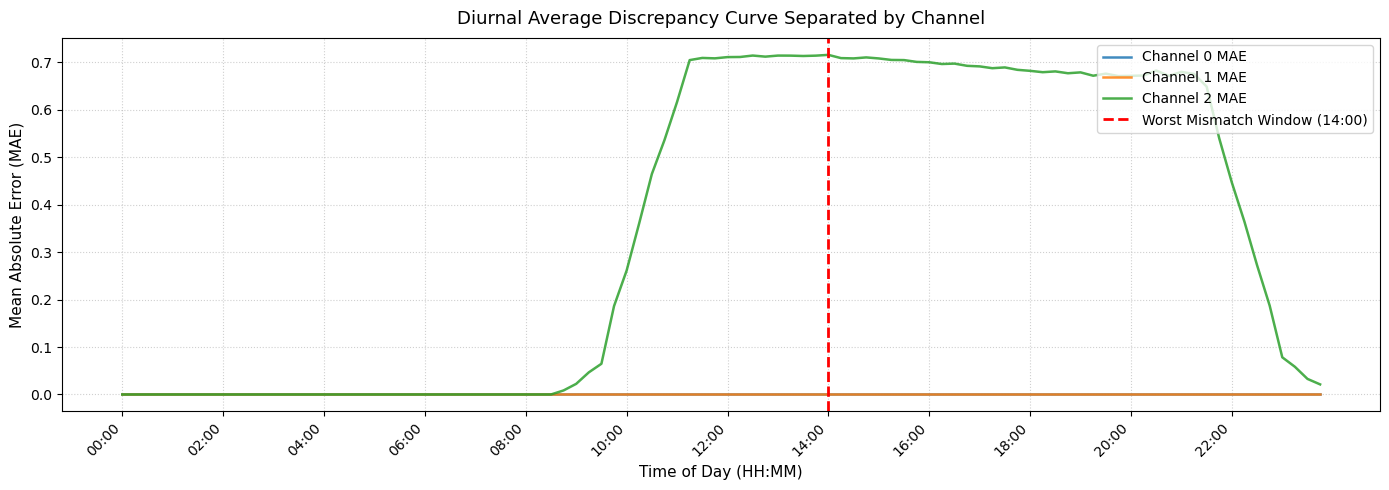

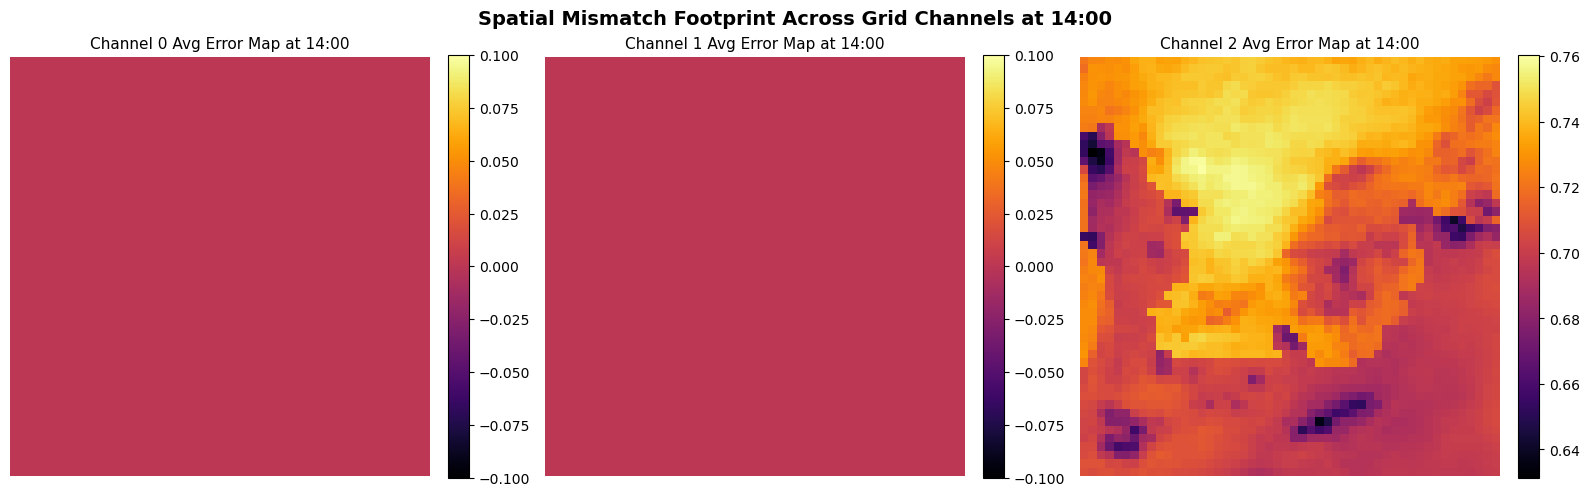

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def analyze_channels_by_time_of_day(syn_path, raw_path, chunk_size=10000):
    """
    Loads NPZ files, evaluates errors for each of the 3 channels independently,
    groups them into 15-minute intervals across the 24-hour cycle, and prints
    exact pixel-level min, max, and mean differences per channel at the peak mismatch period.
    """
    print("Loading NPZ file structures...")
    syn = np.load(syn_path)
    raw_B = np.load(raw_path)
    
    syn_data = syn["data"]      # Shape: (105078, 3, 50, 50)
    raw_data = raw_B["data"]    # Shape: (105078, 3, 50, 50)
    times = pd.to_datetime(syn["time"])
    
    num_timestamps = syn_data.shape[0]
    num_channels = syn_data.shape[1]  # Should be 3
    
    # Array to track MAE per timestamp for each individual channel
    mae_channels = np.zeros((num_timestamps, num_channels))
    
    print(f"Calculating spatial metrics for {num_timestamps} timestamps across {num_channels} channels...")
    for start in range(0, num_timestamps, chunk_size):
        end = min(start + chunk_size, num_timestamps)
        
        # Compute absolute difference matrix for this chunk: (chunk_len, 3, 50, 50)
        chunk_diff = np.abs(syn_data[start:end] - raw_data[start:end])
        
        # Compress only spatial grid dimensions (height=axis 2, width=axis 3) 
        # to preserve separate channel profiles (axis 1)
        mae_channels[start:end] = np.mean(chunk_diff, axis=(2, 3))
        
    # Build DataFrame for diurnal time-of-day mapping
    df = pd.DataFrame({
        'time': times,
        'ch0_mae': mae_channels[:, 0],
        'ch1_mae': mae_channels[:, 1],
        'ch2_mae': mae_channels[:, 2]
    })
    df['time_of_day'] = df['time'].dt.strftime('%H:%M')
    
    # Calculate an overall combined metric to locate the primary peak mismatch window
    df['overall_mae'] = df[['ch0_mae', 'ch1_mae', 'ch2_mae']].mean(axis=1)
    
    # Aggregate timeline rows by their 15-minute diurnal bins
    diurnal_df = df.groupby('time_of_day')[['ch0_mae', 'ch1_mae', 'ch2_mae', 'overall_mae']].mean().reset_index()
    diurnal_df = diurnal_df.sort_values('time_of_day')
    
    # Locate the peak time of day
    peak_idx = diurnal_df['overall_mae'].idxmax()
    peak_time_slot = diurnal_df.loc[peak_idx, 'time_of_day']
    
    # Extract historical indices matching this specific time of day across all years/days
    peak_indices = df[df['time_of_day'] == peak_time_slot].index.tolist()
    
    print("\n" + "="*65)
    print(f"CRITICAL DISCREPANCY DETECTED AT TIME SLOT: {peak_time_slot}")
    print(f"Aggregated across {len(peak_indices)} historical days matching this exact hour/minute.")
    print("="*65)
    
    # Isolate pixel-level min/max boundaries per channel specifically for this time slot
    for c in range(num_channels):
        syn_slice = syn_data[peak_indices, c, :, :]
        raw_slice = raw_data[peak_indices, c, :, :]
        pixel_abs_diff = np.abs(syn_slice - raw_slice)
        
        mean_val = np.mean(pixel_abs_diff)
        min_val = np.min(pixel_abs_diff)
        max_val = np.max(pixel_abs_diff)
        
        print(f"CHANNEL {c} PROPERTIES:")
        print(f"  - Spatial Mean Absolute Error (MAE): {mean_val:.6f}")
        print(f"  - Pixel-Level Minimum Absolute Diff: {min_val:.6f}")
        print(f"  - Pixel-Level Maximum Absolute Diff: {max_val:.6f}")
        print("-" * 45)
        
    return diurnal_df, peak_time_slot, peak_indices, syn_data, raw_data
def plot_channel_trends_inline(diurnal_df, peak_time_slot):
    """Plots diurnal lines for each channel independently inside the notebook."""
    plt.figure(figsize=(14, 5))
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    for c in range(3):
        plt.plot(diurnal_df['time_of_day'], diurnal_df[f'ch{c}_mae'], 
                 label=f'Channel {c} MAE', color=colors[c], alpha=0.85, linewidth=1.8)
        
    plt.axvline(x=peak_time_slot, color='red', linestyle='--', linewidth=2,
                label=f'Worst Mismatch Window ({peak_time_slot})')
    
    plt.title('Diurnal Average Discrepancy Curve Separated by Channel', fontsize=13, pad=10)
    plt.xlabel('Time of Day (HH:MM)', fontsize=11)
    plt.ylabel('Mean Absolute Error (MAE)', fontsize=11)
    
    # Format x-axis labels to break cleanly every 2 hours
    tick_indices = np.arange(0, len(diurnal_df), 8)
    plt.xticks(tick_indices, diurnal_df['time_of_day'].iloc[tick_indices], rotation=45, ha='right')
    
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right', fontsize=10)
    plt.tight_layout()
    plt.show()


def plot_spatial_peak_distribution_inline(syn_data, raw_data, peak_indices, peak_time_slot):
    """
    Renders the exact spatial layout of the absolute differences for all 3 channels 
    averaged over all matching historical days at the peak hour slot.
    """
    # Slice arrays for the specific peak time indices
    syn_peak = syn_data[peak_indices]
    raw_peak = raw_data[peak_indices]
    
    # Calculate the mean absolute spatial error map for the peak slot
    mean_diff_map = np.mean(np.abs(syn_peak - raw_peak), axis=0) # Shape: (3, 50, 50)
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    for c in range(3):
        im = axes[c].imshow(mean_diff_map[c], cmap='inferno')
        axes[c].set_title(f'Channel {c} Avg Error Map at {peak_time_slot}', fontsize=11)
        fig.colorbar(im, ax=axes[c], fraction=0.046, pad=0.04)
        axes[c].axis('off')
        
    plt.suptitle(f'Spatial Mismatch Footprint Across Grid Channels at {peak_time_slot}', fontsize=14, weight='bold', y=0.98)
    plt.tight_layout()
    plt.show()
# Configure your path strings
syn_file = "Data/CAMS/15mins_synthetic_label.npz"
raw_file = "Data/CAMS/ghi_grid2500_3ch_2021_2023_baseline_15mins.npz"

# 1. Run explicit analysis and display precise channel printouts
diurnal_results, worst_slot, target_indices, syn_arr, raw_arr = analyze_channels_by_time_of_day(syn_file, raw_file)

# 2. Display the 24-hour channel line plots inside your notebook
plot_channel_trends_inline(diurnal_results, worst_slot)

# 3. Display the spatial pixel-intensity map for the worst period inside your notebook
plot_spatial_peak_distribution_inline(syn_arr, raw_arr, target_indices, worst_slot)

Loading baseline NPZ structures...
Scanning 26269 snapshots for sharp line anomalies...

DETECTION COMPLETE: Found 142 samples matching a sharp cut pattern.
Match found at Dataset Index:    431 | Timestamp: 2021-01-19 18:00 HKT | Type: Horizontal Cut
Match found at Dataset Index:    455 | Timestamp: 2021-01-20 18:00 HKT | Type: Horizontal Cut
Match found at Dataset Index:    479 | Timestamp: 2021-01-21 18:00 HKT | Type: Horizontal Cut
Match found at Dataset Index:    503 | Timestamp: 2021-01-22 18:00 HKT | Type: Horizontal Cut
Match found at Dataset Index:    527 | Timestamp: 2021-01-23 18:00 HKT | Type: Horizontal Cut
Match found at Dataset Index:    551 | Timestamp: 2021-01-24 18:00 HKT | Type: Horizontal Cut
Match found at Dataset Index:   2267 | Timestamp: 2021-04-06 06:00 HKT | Type: Horizontal Cut
Match found at Dataset Index:   2291 | Timestamp: 2021-04-07 06:00 HKT | Type: Horizontal Cut
Match found at Dataset Index:   2315 | Timestamp: 2021-04-08 06:00 HKT | Type: Horizontal C

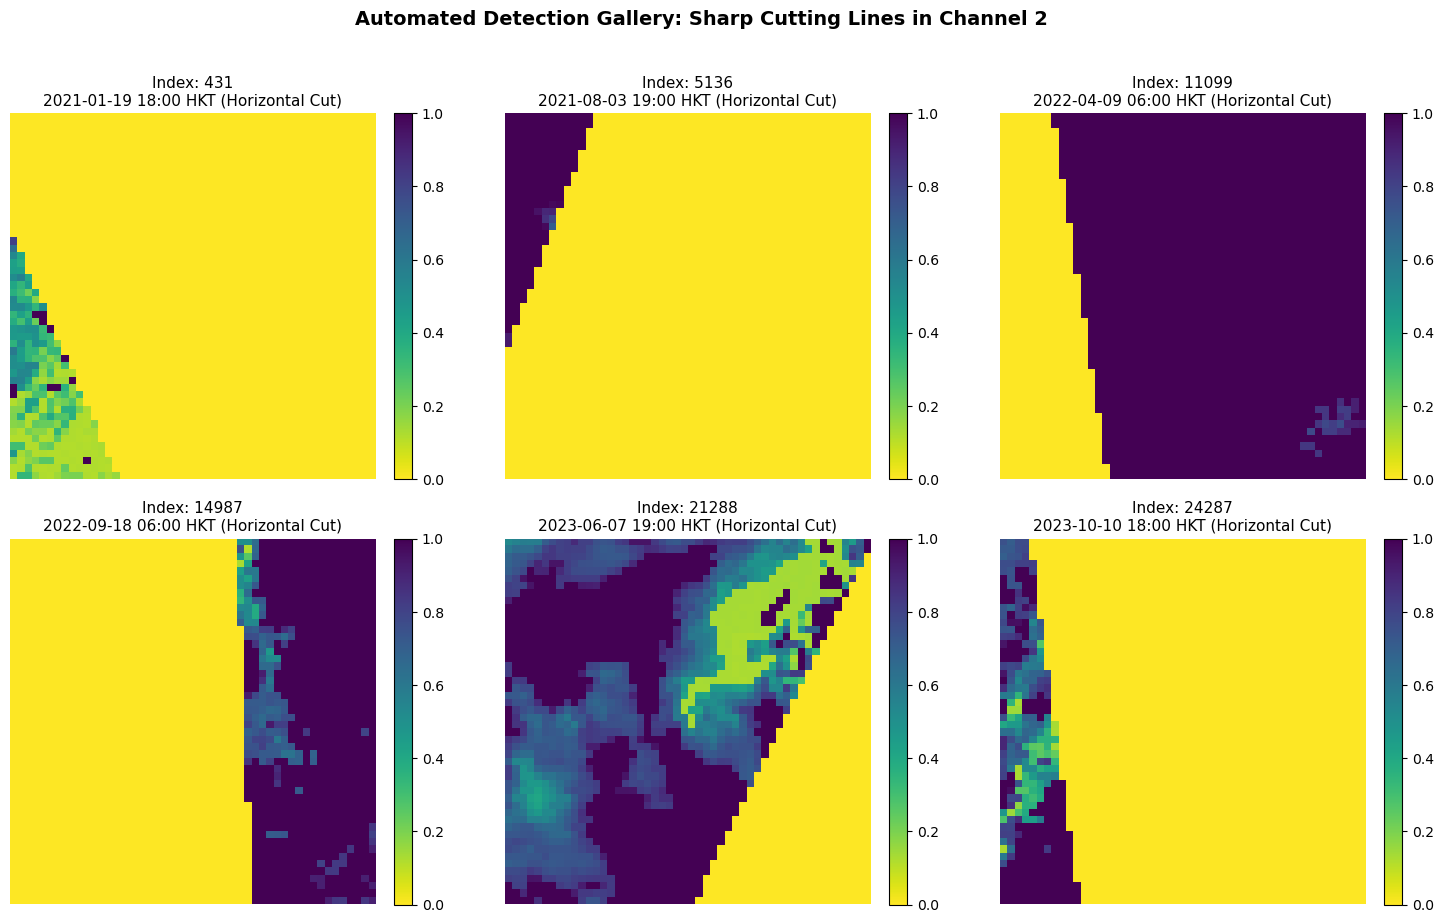

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def auto_detect_sharp_cuts(raw_path, chunk_size=10000, max_display=6):
    """
    Scans the baseline dataset in chunks, automatically detects frames in Channel 2 
    that contain a sharp cutting line separating a zero zone from true values, 
    and renders the representative cases inline.
    """
    print("Loading baseline NPZ structures...")
    raw_B = np.load(raw_path)
    raw_data = raw_B["data"]  # Shape: (105078, 3, 50, 50)
    
    # Convert timestamps to HKT (Hong Kong Time) for clear local tracking
    times = pd.to_datetime(raw_B["time"]) + pd.Timedelta(hours=8)
    
    num_timestamps = raw_data.shape[0]
    channel_idx = 2  # Target Channel 2 (3rd channel index)
    
    detected_indices = []
    detected_types = []
    
    print(f"Scanning {num_timestamps} snapshots for sharp line anomalies...")
    
    for start in range(0, num_timestamps, chunk_size):
        end = min(start + chunk_size, num_timestamps)
        
        # Isolate Channel 2 for the current chunk
        chunk_ch2 = raw_data[start:end, channel_idx, :, :]
        
        # Vectorized pre-filter: Skip frames that are fully zero (night) or fully non-zero (clear day)
        # An anomaly must contain both zero zones and true value zones
        zero_counts = np.sum(chunk_ch2 == 0, axis=(1, 2))
        candidate_relative_indices = np.where((zero_counts > 100) & (zero_counts < 2400))[0]
        
        for rel_idx in candidate_relative_indices:
            global_idx = start + rel_idx
            frame = chunk_ch2[rel_idx]
            
            # Generate binary mask of the zero structure
            mask = (frame == 0).astype(int)
            
            # Find the spatial boundary edges of the zero mask
            edge_h = np.abs(np.diff(mask, axis=1))
            edge_v = np.abs(np.diff(mask, axis=0))
            
            edge_mask = np.zeros_like(mask, dtype=bool)
            edge_mask[:, :-1] |= (edge_h > 0)
            edge_mask[:-1, :] |= (edge_v > 0)
            
            y_coords, x_coords = np.where(edge_mask)
            
            # A valid cutting line across a 50x50 grid must span a reasonable number of pixels
            if len(x_coords) < 15:
                continue
                
            # Perform Eigenvalue Decomposition (PCA) on the edge coordinates to evaluate linearity
            coords = np.column_stack((x_coords, y_coords))
            coords_centered = coords - np.mean(coords, axis=0)
            
            cov_matrix = np.cov(coords_centered.T)
            if cov_matrix.shape == (2, 2):
                eigenvalues, _ = np.linalg.eigh(cov_matrix)
                
                # The smaller eigenvalue represents the variance perpendicular to the cutting edge line.
                # A perfect straight line boundary will have a perpendicular variance near 0.
                perp_variance = eigenvalues[0]
                
                if perp_variance < 0.22:  # Threshold for clean, un-curved pixelated lines
                    # Verify the non-zero region contains actual true values (not sparse noise)
                    if np.mean(frame[mask == 0] > 0.05) > 0.85:
                        detected_indices.append(global_idx)
                        
                        # Determine direction for metadata logging
                        if np.all(np.all(mask == 1, axis=1) == (np.sum(mask, axis=1) == 50)):
                            detected_types.append("Horizontal Cut")
                        elif np.all(np.all(mask == 1, axis=0) == (np.sum(mask, axis=0) == 50)):
                            detected_types.append("Vertical Cut")
                        else:
                            detected_types.append("Diagonal Cut")

    total_found = len(detected_indices)
    print("\n" + "="*60)
    print(f"DETECTION COMPLETE: Found {total_found} samples matching a sharp cut pattern.")
    print("="*60)
    
    if total_found == 0:
        return
        
    # Print out detailed logs for the identified anomalies
    for i in range(min(total_found, 15)):
        idx = detected_indices[i]
        print(f"Match found at Dataset Index: {idx:6d} | Timestamp: {times[idx].strftime('%Y-%m-%d %H:%M')} HKT | Type: {detected_types[i]}")
    if total_found > 15:
        print(f"... and {total_found - 15} more records.")

    # 2. Render representative cases inline within the notebook
    num_to_plot = min(total_found, max_display)
    if num_to_plot > 0:
        # Sample evenly across the detected list to show distinct cases
        sample_indices = np.linspace(0, total_found - 1, num_to_plot, dtype=int)
        
        cols = 3
        rows = (num_to_plot + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4.5 * rows))
        axes = axes.flatten() if num_to_plot > 1 else [axes]
        
        print(f"\nPlotting {num_to_plot} representative cases inside the notebook...")
        for plot_idx, target_idx in enumerate(sample_indices):
            global_idx = detected_indices[target_idx]
            frame_data = raw_data[global_idx, channel_idx, :, :]
            time_str = times[global_idx].strftime('%Y-%m-%d %H:%M')
            cut_type = detected_types[target_idx]
            
            im = axes[plot_idx].imshow(frame_data, cmap='viridis_r', vmin=0, vmax=1)
            axes[plot_idx].set_title(f"Index: {global_idx}\n{time_str} HKT ({cut_type})", fontsize=11)
            axes[plot_idx].axis('off')
            fig.colorbar(im, ax=axes[plot_idx], fraction=0.046, pad=0.04)
            
        # Turn off empty subplots if any
        for p in range(num_to_plot, len(axes)):
            axes[p].axis('off')
            
        plt.suptitle("Automated Detection Gallery: Sharp Cutting Lines in Channel 2", fontsize=14, weight='bold', y=1.02)
        plt.tight_layout()
        plt.show()

# =====================================================================
# EXECUTE DETECTION PIPELINE
# =====================================================================
raw_file = "Data/CAMS/csi_cams_hourly_raw_2021_2023.npz"

# Run auto-detector and display inline results
auto_detect_sharp_cuts(raw_file, max_display=6)

In [22]:
142/26269

0.005405611176672123

Loading NPZ dataset containers...
Scanning 105078 snapshots for sharp line anomalies in baseline...

DETECTION COMPLETE: Identified 574 anomalous samples in Baseline.
Match #1 | Index:     93 | 2021-01-02 17:45 HKT | Profile: Horizontal Cut
Match #2 | Index:   1726 | 2021-01-19 18:00 HKT | Profile: Horizontal Cut
Match #3 | Index:   1822 | 2021-01-20 18:00 HKT | Profile: Horizontal Cut
Match #4 | Index:   1918 | 2021-01-21 18:00 HKT | Profile: Horizontal Cut
Match #5 | Index:   2014 | 2021-01-22 18:00 HKT | Profile: Horizontal Cut
Match #6 | Index:   2110 | 2021-01-23 18:00 HKT | Profile: Horizontal Cut
Match #7 | Index:   2206 | 2021-01-24 18:00 HKT | Profile: Horizontal Cut
Match #8 | Index:   3935 | 2021-02-11 18:15 HKT | Profile: Horizontal Cut
Match #9 | Index:   3985 | 2021-02-12 06:45 HKT | Profile: Horizontal Cut
Match #10 | Index:   4031 | 2021-02-12 18:15 HKT | Profile: Horizontal Cut

Generating side-by-side comparison matrix for 5 selected cases...


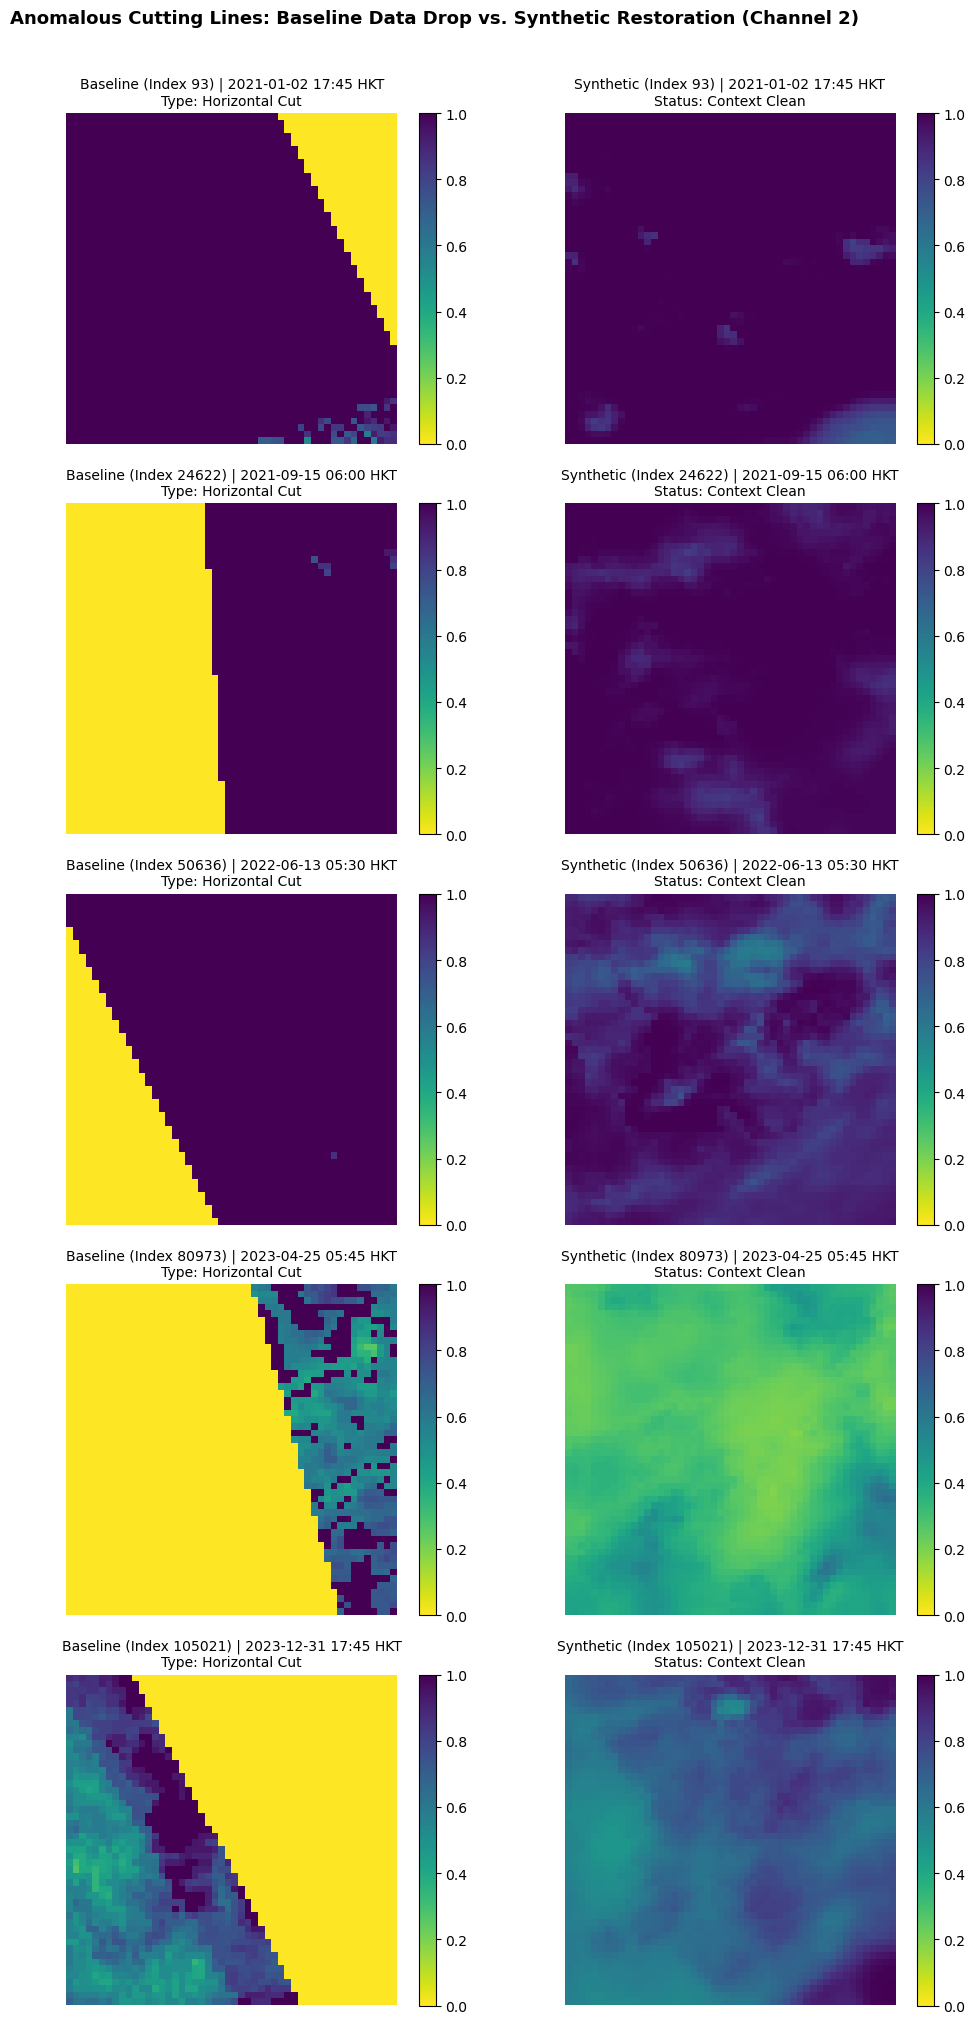

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def auto_detect_and_compare_sharp_cuts(syn_path, raw_path, chunk_size=10000, max_display=5):
    """
    Scans the baseline dataset for sharp line cutting anomalies in Channel 2,
    extracts the matching time frames from the synthetic dataset, and plots 
    the side-by-side comparison directly in the notebook.
    """
    print("Loading NPZ dataset containers...")
    raw_B = np.load(raw_path)
    syn = np.load(syn_path)
    
    raw_data = raw_B["data"]  # Shape: (105078, 3, 50, 50)
    syn_data = syn["data"]    # Shape: (105078, 3, 50, 50)
    
    # Convert timestamps from UTC to HKT (Hong Kong Time)
    times = pd.to_datetime(raw_B["time"]) + pd.Timedelta(hours=8)
    
    num_timestamps = raw_data.shape[0]
    channel_idx = 2  # Target Channel 2 (3rd channel index)
    
    detected_indices = []
    detected_types = []
    
    print(f"Scanning {num_timestamps} snapshots for sharp line anomalies in baseline...")
    
    for start in range(0, num_timestamps, chunk_size):
        end = min(start + chunk_size, num_timestamps)
        
        # Isolate Channel 2 for the current chunk
        chunk_ch2 = raw_data[start:end, channel_idx, :, :]
        
        # Vectorized Pre-filter: Focus on steps containing a mixture of zeros and valid values
        zero_counts = np.sum(chunk_ch2 == 0, axis=(1, 2))
        candidate_relative_indices = np.where((zero_counts > 100) & (zero_counts < 2400))[0]
        
        for rel_idx in candidate_relative_indices:
            global_idx = start + rel_idx
            frame = chunk_ch2[rel_idx]
            
            # Generate binary mask of the zero structure
            mask = (frame == 0).astype(int)
            
            # Extract edge transitions
            edge_h = np.abs(np.diff(mask, axis=1))
            edge_v = np.abs(np.diff(mask, axis=0))
            
            edge_mask = np.zeros_like(mask, dtype=bool)
            edge_mask[:, :-1] |= (edge_h > 0)
            edge_mask[:-1, :] |= (edge_v > 0)
            
            y_coords, x_coords = np.where(edge_mask)
            
            # Minimum edge pixel constraint to confirm a continuous straight line
            if len(x_coords) < 15:
                continue
                
            # Perform PCA via Eigenvalue Decomposition on edge points to find geometric linearity
            coords = np.column_stack((x_coords, y_coords))
            coords_centered = coords - np.mean(coords, axis=0)
            
            cov_matrix = np.cov(coords_centered.T)
            if cov_matrix.shape == (2, 2):
                eigenvalues, _ = np.linalg.eigh(cov_matrix)
                perp_variance = eigenvalues[0] # Smaller eigenvalue = variance perpendicular to the edge
                
                # Low perpendicular variance indicates a highly straight cutting edge boundary line
                if perp_variance < 0.22:
                    # Confirm that the illuminated side contains meaningful positive measurements
                    if np.mean(frame[mask == 0] > 0.05) > 0.85:
                        detected_indices.append(global_idx)
                        
                        # Identify line orientation for label contexts
                        if np.all(np.all(mask == 1, axis=1) == (np.sum(mask, axis=1) == 50)):
                            detected_types.append("Horizontal Cut")
                        elif np.all(np.all(mask == 1, axis=0) == (np.sum(mask, axis=0) == 50)):
                            detected_types.append("Vertical Cut")
                        else:
                            detected_types.append("Diagonal Cut")

    total_found = len(detected_indices)
    print("\n" + "="*65)
    print(f"DETECTION COMPLETE: Identified {total_found} anomalous samples in Baseline.")
    print("="*65)
    
    if total_found == 0:
        print("No sharp line cuts matching criteria found.")
        return
        
    # Log details for the first few findings to the console
    for i in range(min(total_found, 10)):
        idx = detected_indices[i]
        print(f"Match #{i+1} | Index: {idx:6d} | {times[idx].strftime('%Y-%m-%d %H:%M')} HKT | Profile: {detected_types[i]}")
        
    # 2. Render side-by-side comparison panels 
    num_to_plot = min(total_found, max_display)
    if num_to_plot > 0:
        # Uniformly sample instances from across the list to give a varied representation
        sample_indices = np.linspace(0, total_found - 1, num_to_plot, dtype=int)
        
        # Set up a strict vertical grid row structure (Left = Baseline, Right = Synthetic)
        fig, axes = plt.subplots(num_to_plot, 2, figsize=(11, 4 * num_to_plot))
        
        # Safe handling if only a single row is plotted
        if num_to_plot == 1:
            axes = np.expand_dims(axes, axis=0)
            
        print(f"\nGenerating side-by-side comparison matrix for {num_to_plot} selected cases...")
        for plot_idx, target_idx in enumerate(sample_indices):
            global_idx = detected_indices[target_idx]
            time_str = times[global_idx].strftime('%Y-%m-%d %H:%M')
            cut_type = detected_types[target_idx]
            
            # Isolate matching frame matrices for Channel 2
            baseline_frame = raw_data[global_idx, channel_idx, :, :]
            synthetic_frame = syn_data[global_idx, channel_idx, :, :]
            
            # Left Column: Baseline Frame (With sharp anomaly line)
            im_base = axes[plot_idx, 0].imshow(baseline_frame, cmap='viridis_r', vmin=0, vmax=1)
            axes[plot_idx, 0].set_title(f"Baseline (Index {global_idx}) | {time_str} HKT\nType: {cut_type}", fontsize=10)
            axes[plot_idx, 0].axis('off')
            fig.colorbar(im_base, ax=axes[plot_idx, 0], fraction=0.046, pad=0.04)
            
            # Right Column: Synthetic Frame (The clean target matching state)
            im_syn = axes[plot_idx, 1].imshow(synthetic_frame, cmap='viridis_r', vmin=0, vmax=1)
            axes[plot_idx, 1].set_title(f"Synthetic (Index {global_idx}) | {time_str} HKT\nStatus: Context Clean", fontsize=10)
            axes[plot_idx, 1].axis('off')
            fig.colorbar(im_syn, ax=axes[plot_idx, 1], fraction=0.046, pad=0.04)
            
        plt.suptitle("Anomalous Cutting Lines: Baseline Data Drop vs. Synthetic Restoration (Channel 2)", 
                     fontsize=13, weight='bold', y=1.01)
        plt.tight_layout()
        plt.show()

# =====================================================================
# RUN THE SCRIPT
# =====================================================================
syn_file = "Data/CAMS/15mins_synthetic_label.npz"
raw_file = "Data/CAMS/ghi_grid2500_3ch_2021_2023_baseline_15mins.npz"

# max_display determines how many side-by-side comparison rows will draw inline
auto_detect_and_compare_sharp_cuts(syn_file, raw_file, max_display=5)

In [29]:
np.load("Data/CAMS/15mins_synthetic_label.npz").keys()

KeysView(NpzFile 'Data/CAMS/15mins_synthetic_label.npz' with keys: time, data)

In [ ]:
# Quick analysis snippet
data_out = np.load("Data/CAMS/csi_cams_hourly_raw_2021_2023.npz")["data"]
t_out = np.load("Data/CAMS/csi_cams_hourly_raw_2021_2023.npz")["time"]
is_missing = np.all(data_out[:, 2, :, :] == -1.0, axis=(1, 2))
missing_times_hkt = pd.to_datetime(t_out[is_missing], utc=True).tz_convert('Asia/Hong_Kong')

# Group by hour to see exactly when the matching is failing
print(missing_times_hkt.hour.value_counts().sort_index())

# Group the missing timestamps by YEAR and MONTH
print("Missing by Year:")
print(missing_times_hkt.year.value_counts().sort_index())

print("\nMissing by Month:")
print(missing_times_hkt.month.value_counts().sort_index())

0     24
1     18
2     18
3     25
4     38
5     27
6      4
18     5
19    15
20     8
21     9
22    32
23    28
Name: count, dtype: int64
Missing by Year:
2021     64
2022    120
2023     67
Name: count, dtype: int64

Missing by Month:
1     17
2     30
3     37
4     12
5     10
6     14
7     52
8      6
9     28
10    17
11    11
12    17
Name: count, dtype: int64


In [37]:
import numpy as np
import pandas as pd

# Quick analysis snippet for hourly time gaps
t_out = np.load("Data/CAMS/csi_cams_hourly_raw_2021_2023.npz")["time"]

# Convert raw format string to HKT (Hong Kong Time)
times_hkt = pd.to_datetime(t_out.astype(str), utc=True).tz_convert('Asia/Hong_Kong')

# 1. Generate a perfect continuous hourly reference timeline
perfect_timeline = pd.date_range(start=times_hkt.min(), end=times_hkt.max(), freq='1h')

# 2. Identify which expected hours are completely missing from your actual file
missing_times_hkt = perfect_timeline[~perfect_timeline.isin(times_hkt)]

# Group by hour to see exactly when the timeline is skipping steps
print("Missing Gaps by Hour:")
print(missing_times_hkt.hour.value_counts().sort_index())

# Group the missing timestamps by YEAR and MONTH
print("\nMissing Gaps by Year:")
print(missing_times_hkt.year.value_counts().sort_index())

print("\nMissing Gaps by Month:")
print(missing_times_hkt.month.value_counts().sort_index())

Missing Gaps by Hour:
Series([], Name: count, dtype: int64)

Missing Gaps by Year:
Series([], Name: count, dtype: int64)

Missing Gaps by Month:
Series([], Name: count, dtype: int64)


In [39]:
np.load("Data/CAMS/csi_synthetic_cams_clone.npz")["data"].shape

(26269, 3, 50, 50)

In [76]:
import numpy as np
import pandas as pd

def audit_output_quality(file_path, csi_channel=2):
    print(f"🔍 Starting Data Quality Audit for: {file_path}\n" + "="*50)
    
    # Load the compressed npz file
    loaded = np.load(file_path)
    
    # 1. Verify Structure and Shapes
    print("\n[📊 STEP 1: Shape & Structure Check]")
    for key in loaded.files:
        arr = loaded[key]
        print(f"  • Key: '{key:<5}' | Shape: {str(arr.shape):<18} | Dtype: {arr.dtype}")
        
    t_out = loaded['time']
    data_out = loaded['data']
    
    # 2. Verify Time Resolution
    print("\n[⏱️ STEP 2: Resolution & Interval Check]")
    dt_out = pd.to_datetime(t_out, utc=True)
    intervals = pd.Series(dt_out).sort_values().diff()
    
    print("  Top 3 most frequent intervals found:")
    print(intervals.value_counts().head(3))
    
    # Display timeline boundaries
    print(f"  • Start Time: {dt_out.min()}")
    print(f"  • End Time:   {dt_out.max()}")
    
    # 3. Scan for Missing Data (NaNs / Infs)
    print("\n[🛑 STEP 3: Missing & Empty Value Scan]")
    total_nans = np.isnan(data_out).sum()
    channel_nans = np.isnan(data_out[:, csi_channel, :, :]).sum()
    total_infs = np.isinf(data_out).sum()
    
    print(f"  • NaNs in entire dataset:        {total_nans}")
    print(f"  • NaNs in injected channel ({csi_channel}): {channel_nans}")
    print(f"  • Infinite values found:         {total_infs}")
    
    # 4. Check for Blank/Dead Frames (Optional sanity check)
    # Checks if any injected frames contain only flat zeros
    zero_frames = np.all(data_out[:, csi_channel, :, :] == 0, axis=(1, 2)).sum()
    print(f"  • All-zero (empty) frames in channel {csi_channel}: {zero_frames} / {len(data_out)}")
    
    print("\n" + "="*50 + "\n📋 Audit Complete.")

# Run the audit (replace with your actual output path)
audit_output_quality(path_final_output, csi_channel=2)

🔍 Starting Data Quality Audit for: Data/CAMS/15mins_synthetic.npz

[📊 STEP 1: Shape & Structure Check]
  • Key: 'time ' | Shape: (140214,)          | Dtype: datetime64[ns]
  • Key: 'data ' | Shape: (140214, 3, 50, 50) | Dtype: float32

[⏱️ STEP 2: Resolution & Interval Check]
  Top 3 most frequent intervals found:
0 days 00:15:00    140213
Name: count, dtype: int64
  • Start Time: 2021-01-01 10:30:00+00:00
  • End Time:   2024-12-31 23:45:00+00:00

[🛑 STEP 3: Missing & Empty Value Scan]
  • NaNs in entire dataset:        0
  • NaNs in injected channel (2): 0
  • Infinite values found:         0
  • All-zero (empty) frames in channel 2: 17346 / 140214

📋 Audit Complete.


In [97]:
import numpy as np
import pandas as pd

# 1. Load the dataset
file_path = "Data/CAMS/15mins_synthetic.npz"
loaded = np.load(file_path)
t_out = loaded['time']

# 2. Convert to a standard pandas datetime format
dt_out = pd.to_datetime(t_out, utc=True)

# 3. Calculate duplication statistics
total_records = len(dt_out)
num_duplicates = dt_out.duplicated().sum()
is_perfectly_monotonic = dt_out.is_monotonic_increasing

print("="*50)
print("⏳ TIMESTEP DUPLICATION AUDIT")
print("="*50)
print(f"• Total timestamps in dataset: {total_records}")
print(f"• Number of duplicated rows:   {num_duplicates}")
print(f"• Duplication Percentage:      {(num_duplicates / total_records) * 100:.4f}%")
print(f"• Is strictly chronological?   {is_perfectly_monotonic}")
print("="*50)

# 4. If duplicates exist, isolate and investigate them
if num_duplicates > 0:
    print("\n🚨 EXAMPLES OF DUPLICATED TIMESTAMPS & FREQUENCY:")
    # keep=False marks all occurrences of a duplicate so we can count them
    duplicated_series = pd.Series(dt_out)[pd.Series(dt_out).duplicated(keep=False)]
    print(duplicated_series.value_counts().head(15))
    print("="*50)
else:
    print("\n✅ Excellent! Every single 15-minute timestep appears exactly once.")
    print("="*50)

⏳ TIMESTEP DUPLICATION AUDIT
• Total timestamps in dataset: 140214
• Number of duplicated rows:   0
• Duplication Percentage:      0.0000%
• Is strictly chronological?   True

✅ Excellent! Every single 15-minute timestep appears exactly once.


In [92]:
import numpy as np
import pandas as pd

# 1. Load the dataset
file_path = path_final_output
loaded = np.load(file_path)

t_out = loaded['time']
data_out = loaded['data']

# 2. Identify all-zero frames in Channel 2
is_zero_frame = np.all(data_out[:, 2, :, :] == 0, axis=(1, 2))

# 3. Convert the entire timeline to HKT (UTC -> Asia/Hong_Kong)
dt_utc = pd.to_datetime(t_out, utc=True)
dt_hkt = dt_utc.tz_convert('Asia/Hong_Kong')

# 4. Generate clean time strings directly (e.g., "00:00 HKT", "00:15 HKT")
hkt_time_strings = dt_hkt.strftime('%H:%M HKT')

# 5. Build DataFrame and Group by the clean time string
df_stats = pd.DataFrame({
    'Time (HKT)': hkt_time_strings,
    'Is_Zero': is_zero_frame
})

grouped = df_stats.groupby('Time (HKT)').agg(
    Zero_Frames=('Is_Zero', 'sum'),
    Total_Frames=('Is_Zero', 'count')
)

# Calculate the percentage
grouped['Zero_Percentage'] = (grouped['Zero_Frames'] / grouped['Total_Frames']) * 100

# Sort the index so it runs chronologically from 00:00 to 23:45
grouped = grouped.sort_index()

# Print out the clean table
pd.set_option('display.max_rows', 100)
print("="*70)
print("⏰ 15-MINUTE ZERO-FRAME PROFILE (DIRECT HKT TIME)")
print("="*70)
print(grouped)
print("="*70)

⏰ 15-MINUTE ZERO-FRAME PROFILE (DIRECT HKT TIME)
            Zero_Frames  Total_Frames  Zero_Percentage
Time (HKT)                                            
00:00 HKT           376          1461        25.735797
00:15 HKT           368          1461        25.188227
00:30 HKT           376          1461        25.735797
00:45 HKT           368          1461        25.188227
01:00 HKT           373          1461        25.530459
01:15 HKT           368          1461        25.188227
01:30 HKT           373          1461        25.530459
01:45 HKT           368          1461        25.188227
02:00 HKT           371          1461        25.393566
02:15 HKT           368          1461        25.188227
02:30 HKT           375          1461        25.667351
02:45 HKT           368          1461        25.188227
03:00 HKT           378          1461        25.872690
03:15 HKT           368          1461        25.188227
03:30 HKT           376          1461        25.735797
03:45 HKT       

In [84]:
full_cams_15 = np.load("Data/CAMS/ghi_grid2500_2ch_15mins.npz")
full_cams_15["data"].shape

(140214, 2, 50, 50)

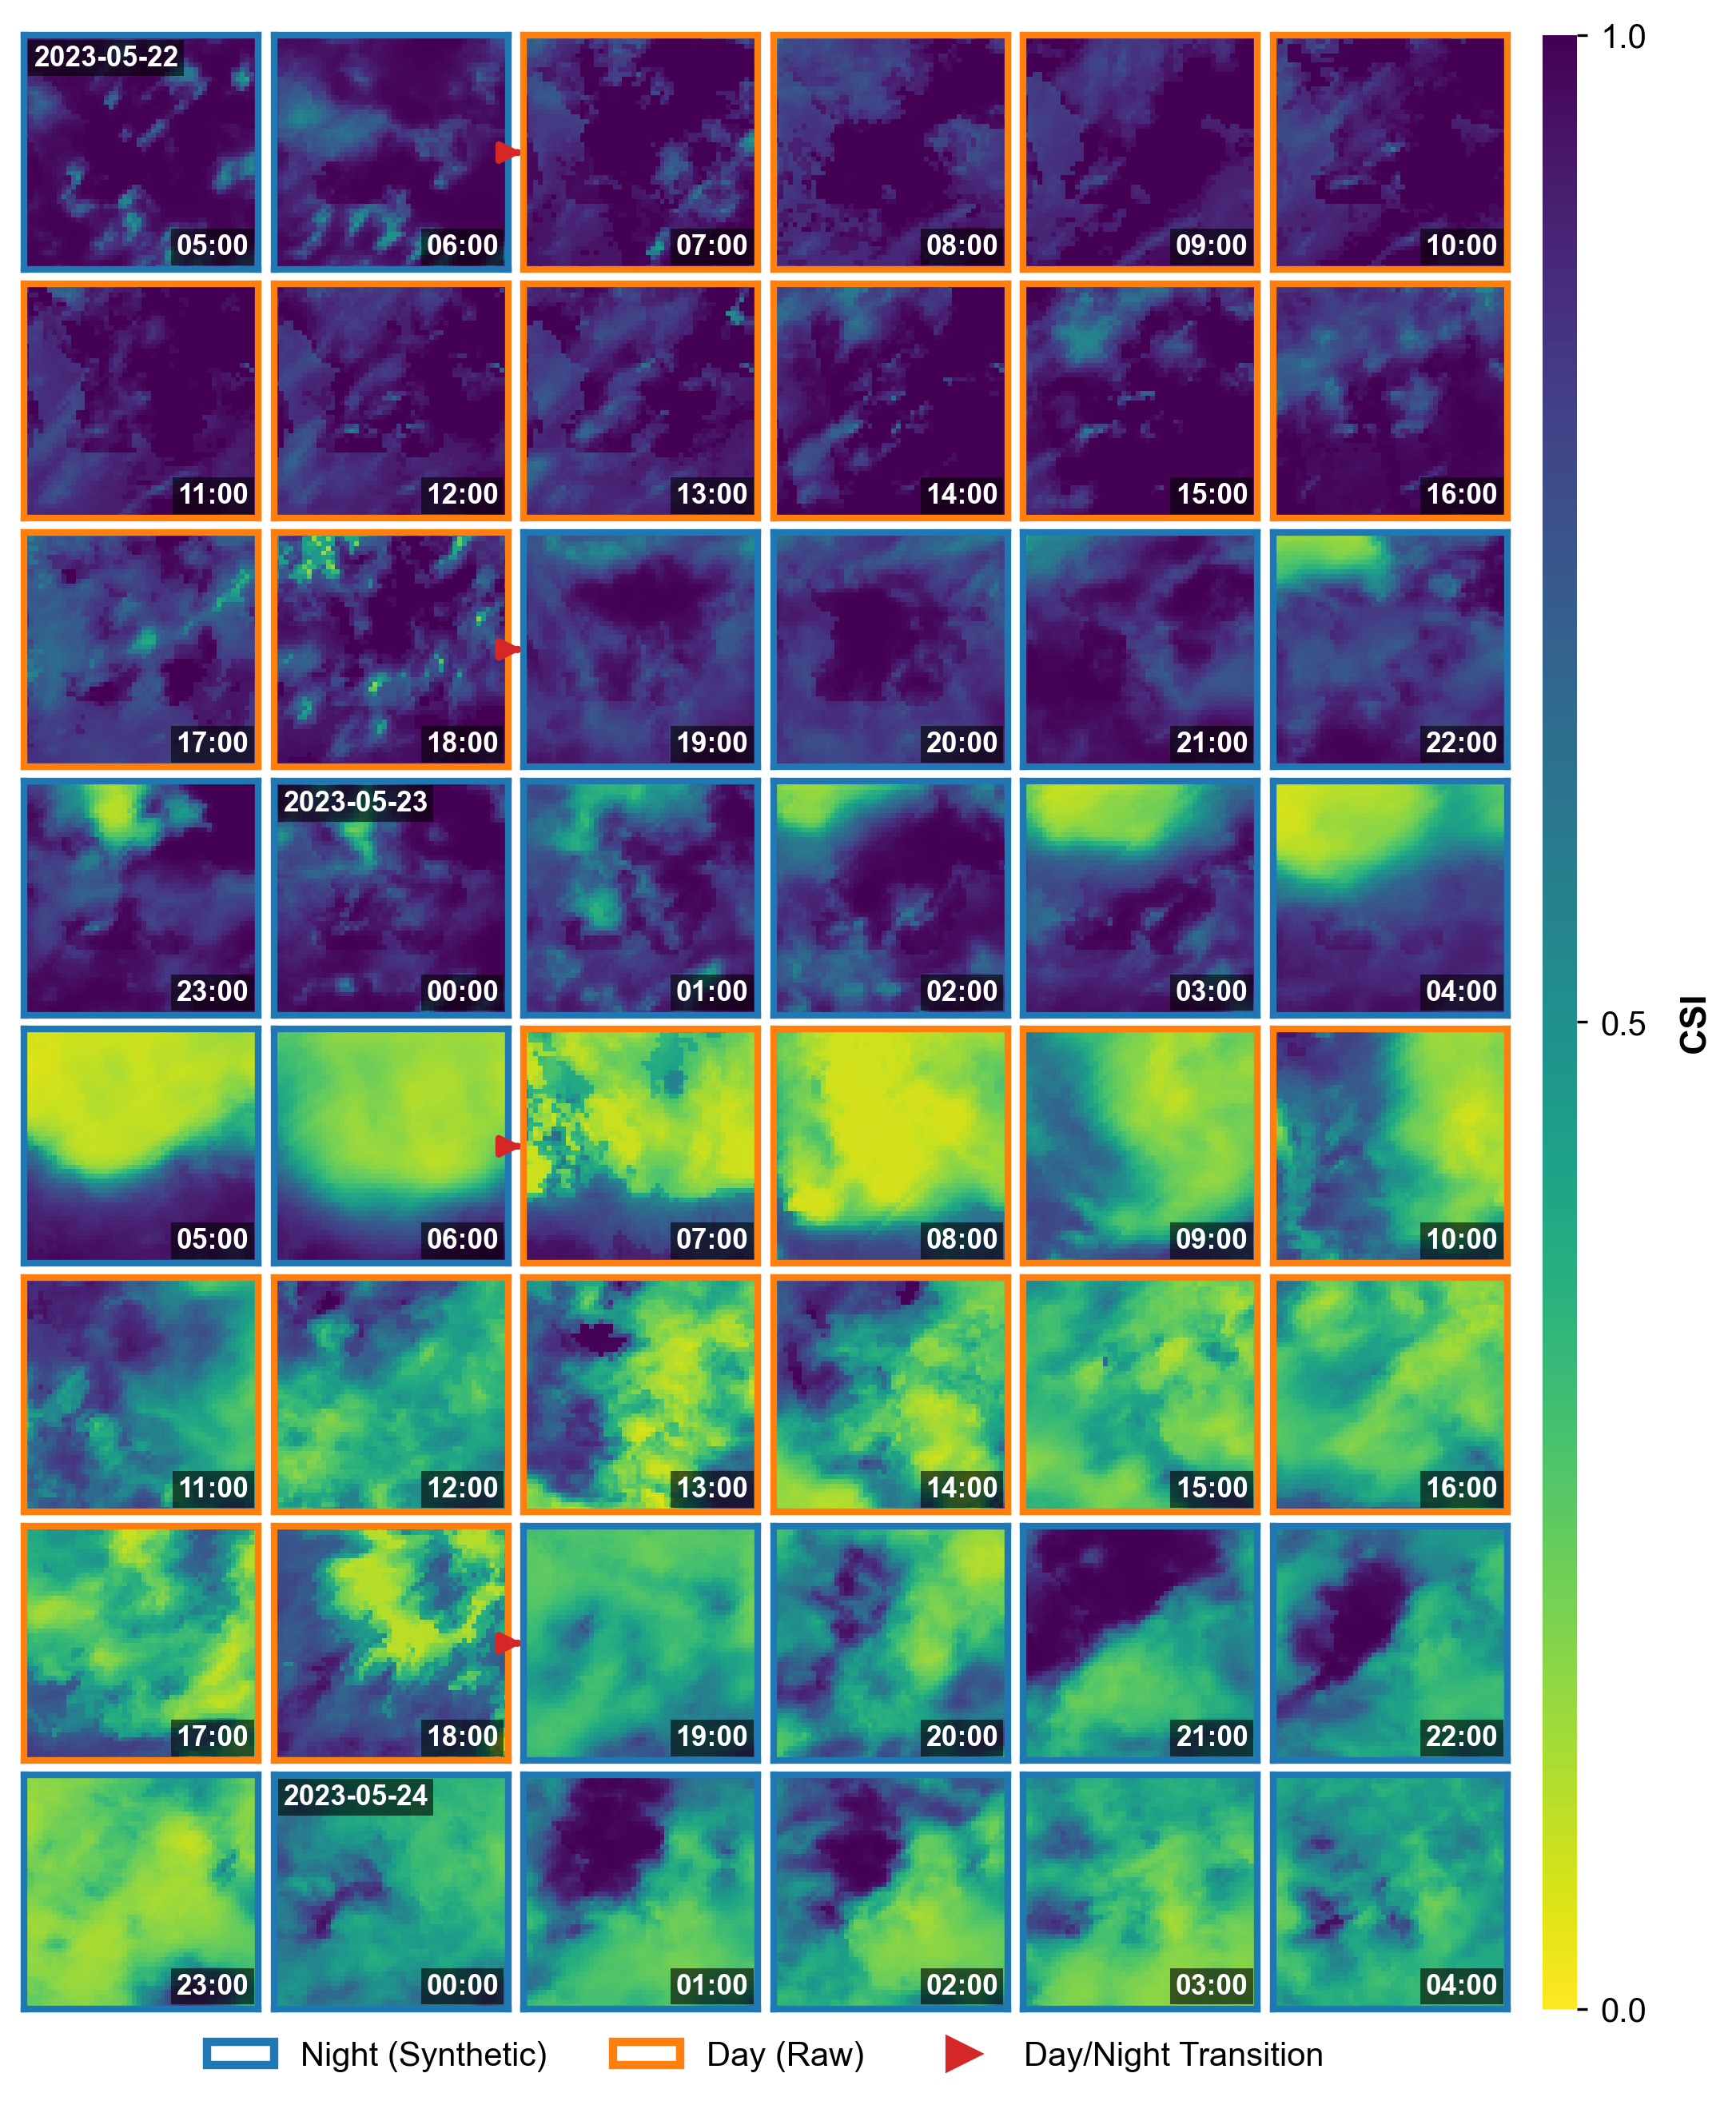

In [19]:
plot_syn_csi(csi_h, hours, is_day_h, start_idx=20496+(24*11), num_steps=48)
# plot_syn_csi(csi_h, hours, is_day_h, start_idx=20496+(24*11), num_steps=48)

## 5. Visual Verification

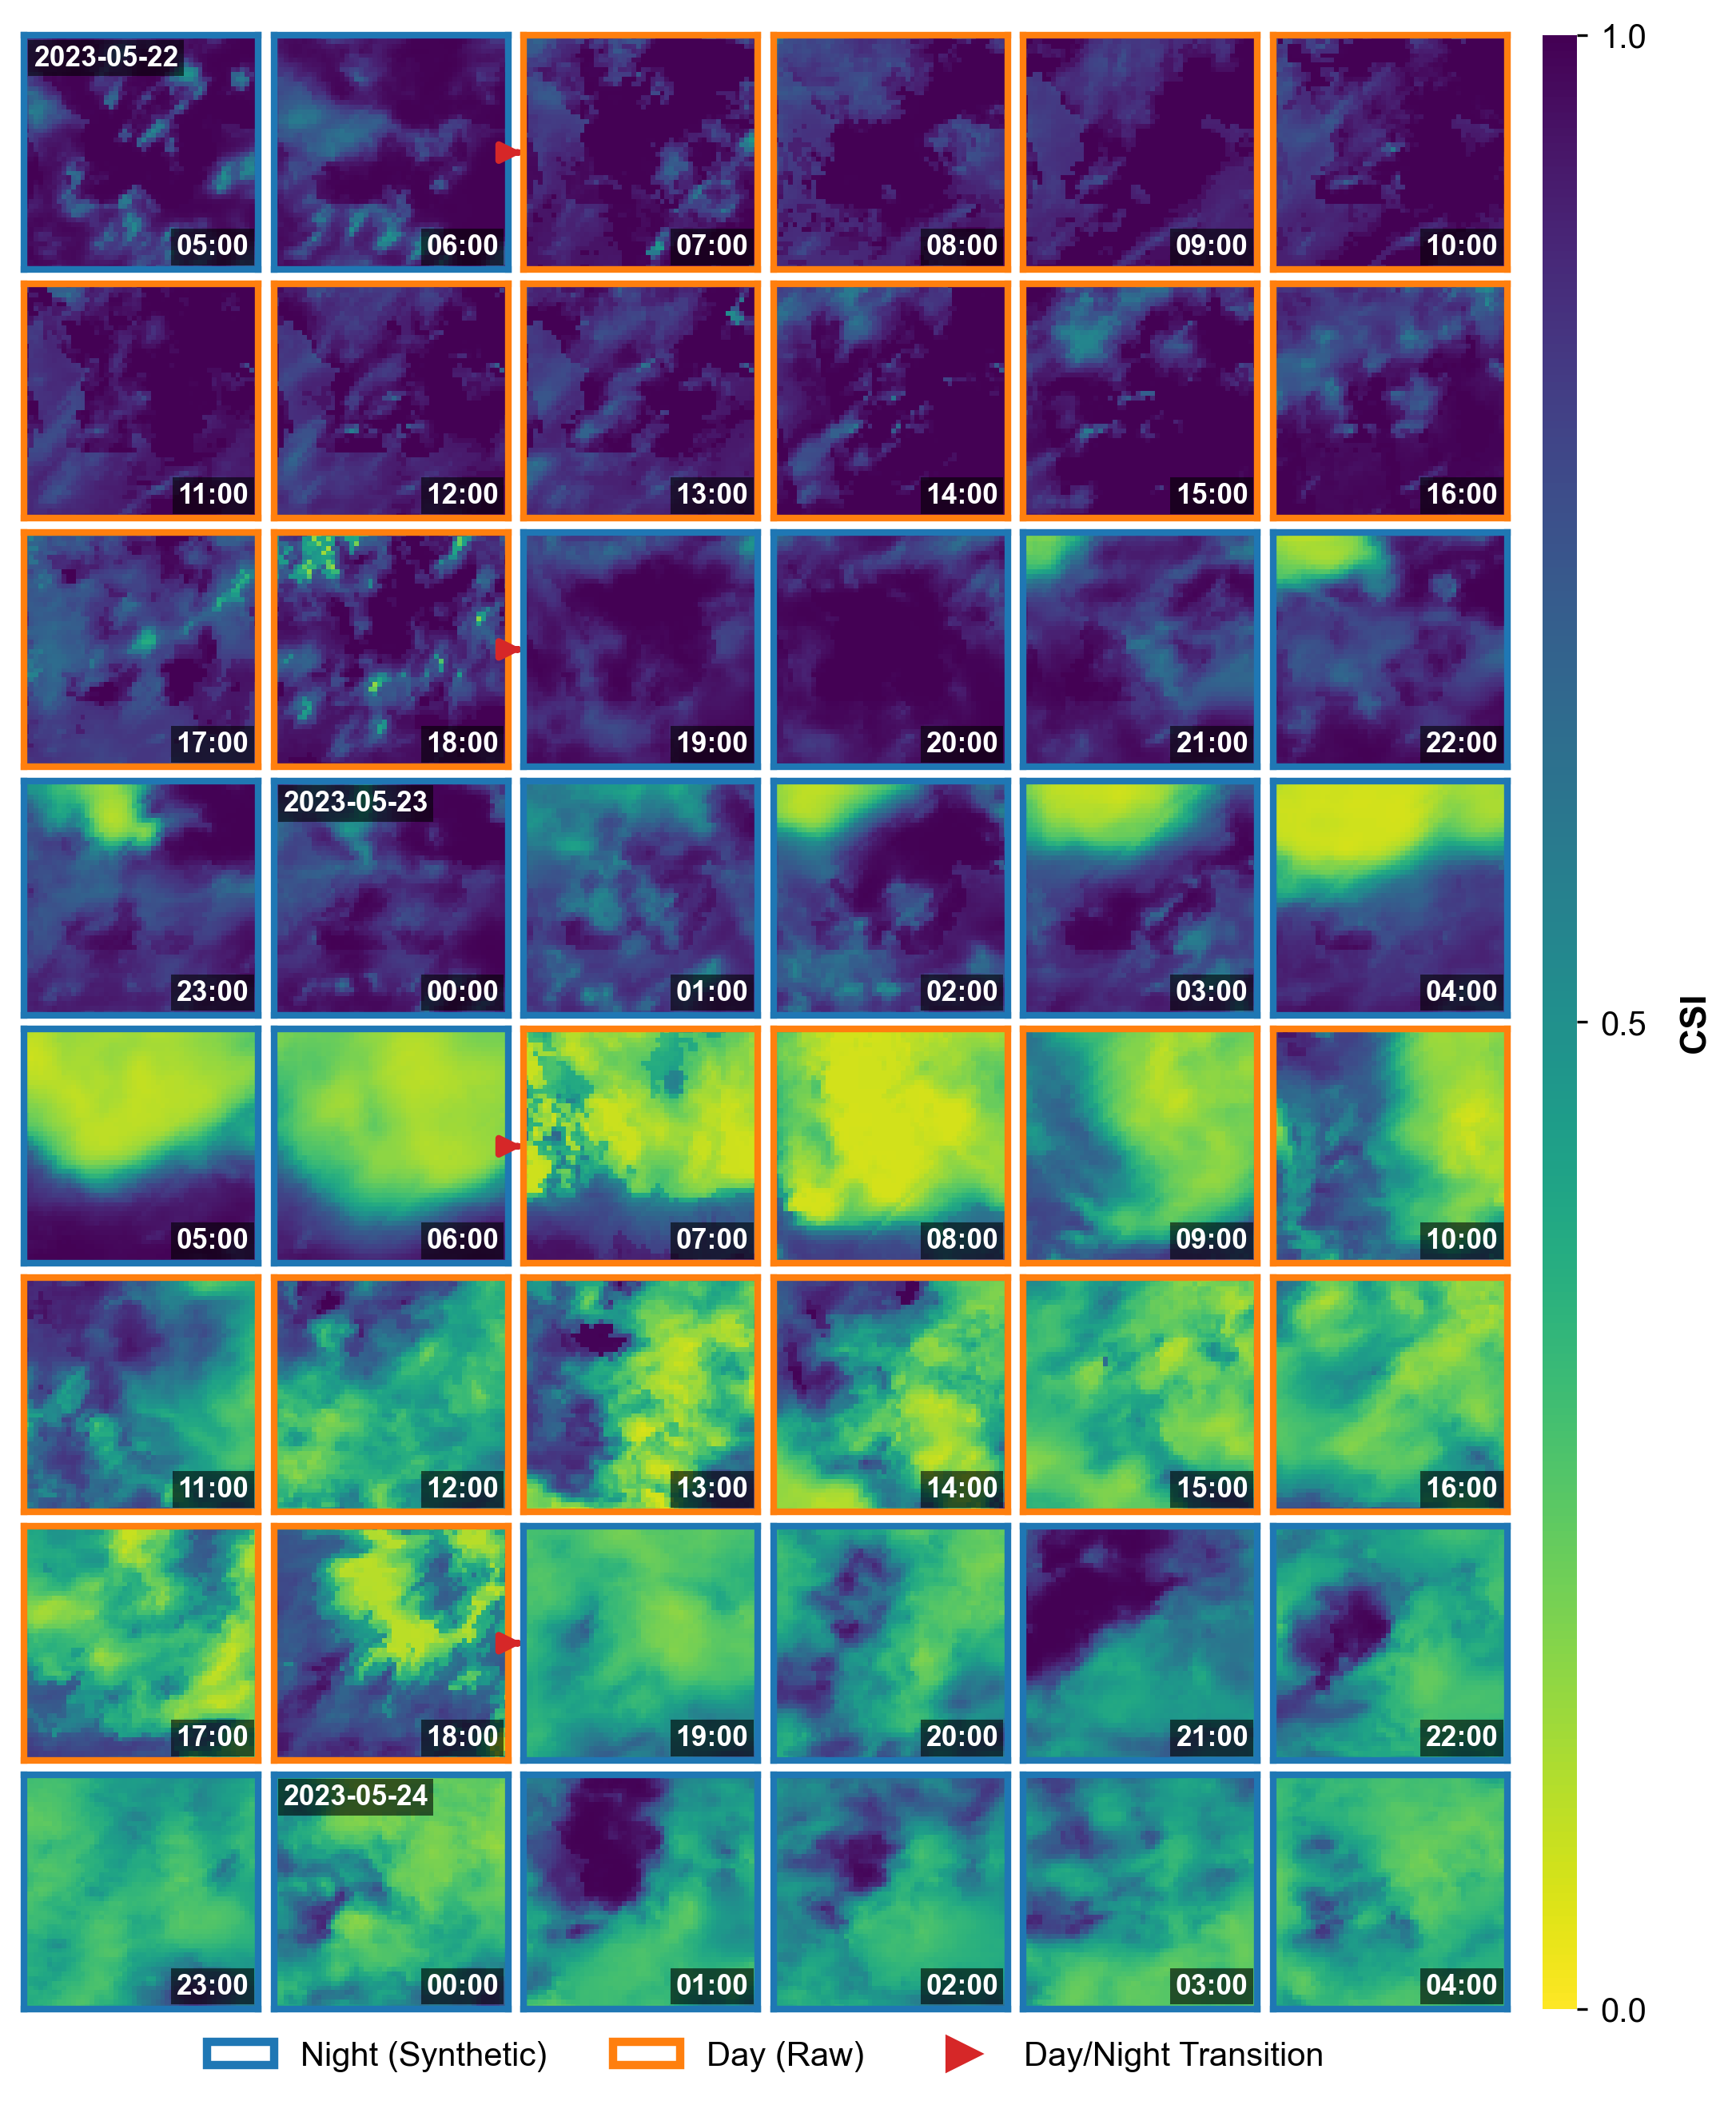

In [15]:
plot_syn_csi(csi_h, hours, is_day_h, start_idx=20496+(24*11), num_steps=48)

In [33]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

def compare_csi_npz(path1, path2):
    print(f"Comparing:\n1: {path1}\n2: {path2}\n" + "-"*50)
    
    # 1. Load files
    data1 = np.load(path1)
    data2 = np.load(path2)
    
    # Check if keys match
    if set(data1.files) != set(data2.files):
        print(f"⚠️ Key mismatch! \nFile 1 keys: {data1.files}\nFile 2 keys: {data2.files}")
    
    csi1, time1 = data1['csi'], data1['time_hourly']
    csi2, time2 = data2['csi'], data2['time_hourly']
    
    # 2. Check Shapes
    print(f"Shape Comparison:")
    print(f"File 1 CSI: {csi1.shape} | Time: {time1.shape}")
    print(f"File 2 CSI: {csi2.shape} | Time: {time2.shape}")
    
    if csi1.shape != csi2.shape:
        print("❌ Shapes do not match! Cannot perform element-wise comparison.")
        return

    # 3. Check Temporal Alignment
    time_diff = np.sum(time1 != time2)
    if time_diff == 0:
        print("✅ Timestamps: Perfect match.")
    else:
        print(f"❌ Timestamps: {time_diff} indices differ.")

    # 4. Numerical Similarity (Stats)
    # We flatten the spatial dimensions to treat it as one big vector
    c1_flat = csi1.flatten()
    c2_flat = csi2.flatten()
    
    # Mask out NaNs if any exist to avoid breaking stats
    mask = ~np.isnan(c1_flat) & ~np.isnan(c2_flat)
    c1_clean = c1_flat[mask]
    c2_clean = c2_flat[mask]

    mae = mean_absolute_error(c1_clean, c2_clean)
    rmse = np.sqrt(mean_squared_error(c1_clean, c2_clean))
    correlation = np.corrcoef(c1_clean, c2_clean)[0, 1]
    max_diff = np.max(np.abs(c1_clean - c2_clean))
    
    print(f"\nNumeric Similarity Results:")
    print(f"Mean Absolute Error (MAE): {mae:.6f}")
    print(f"Root Mean Sq. Error (RMSE): {rmse:.6f}")
    print(f"Pearson Correlation:      {correlation:.6f}")
    print(f"Max Pointwise Difference: {max_diff:.6f}")
    
    if mae == 0 and max_diff == 0:
        print("\n💎 Result: The two files are IDENTICAL.")
    elif correlation > 0.99:
        print("\n📈 Result: The files are HIGHLY similar (likely minor floating point diffs or tiny prep changes).")
    else:
        print("\n📉 Result: The files have significant differences.")

# Usage:
compare_csi_npz("Data/syntheticCSI/csi_synthetic_hourly_merged_day_night_fuzzy_pub_temp_norm.npz", "Data/syntheticCSI/csi_synthetic_hourly_merged_day_night_fuzzy.npz")

Comparing:
1: Data/syntheticCSI/csi_synthetic_hourly_merged_day_night_fuzzy_pub_temp_norm.npz
2: Data/syntheticCSI/csi_synthetic_hourly_merged_day_night_fuzzy.npz
--------------------------------------------------
Shape Comparison:
File 1 CSI: (26104, 1, 50, 50) | Time: (26104,)
File 2 CSI: (26104, 1, 50, 50) | Time: (26104,)
✅ Timestamps: Perfect match.

Numeric Similarity Results:
Mean Absolute Error (MAE): 0.029868
Root Mean Sq. Error (RMSE): 0.063721
Pearson Correlation:      0.979036
Max Pointwise Difference: 0.897481

📉 Result: The files have significant differences.


Rank  | Timestamp (UTC)      | Max Diff   | Idx   
--------------------------------------------------
#1    | 2023-06-07 19:00:00+00:00 | 0.9040     | 21162 
#2    | 2021-05-25 21:00:00+00:00 | 0.8375     | 3441  
#3    | 2022-03-26 12:00:00+00:00 | 0.8335     | 10710 
#4    | 2021-01-15 22:00:00+00:00 | 0.8210     | 343   
#5    | 2023-07-29 12:00:00+00:00 | 0.8021     | 22396 
#6    | 2021-10-09 18:00:00+00:00 | 0.7921     | 6710  
#7    | 2023-06-25 21:00:00+00:00 | 0.7890     | 21592 
#8    | 2022-08-08 15:00:00+00:00 | 0.7848     | 13931 
#9    | 2021-01-15 21:00:00+00:00 | 0.7846     | 342   
#10   | 2021-07-20 17:00:00+00:00 | 0.7764     | 4776  


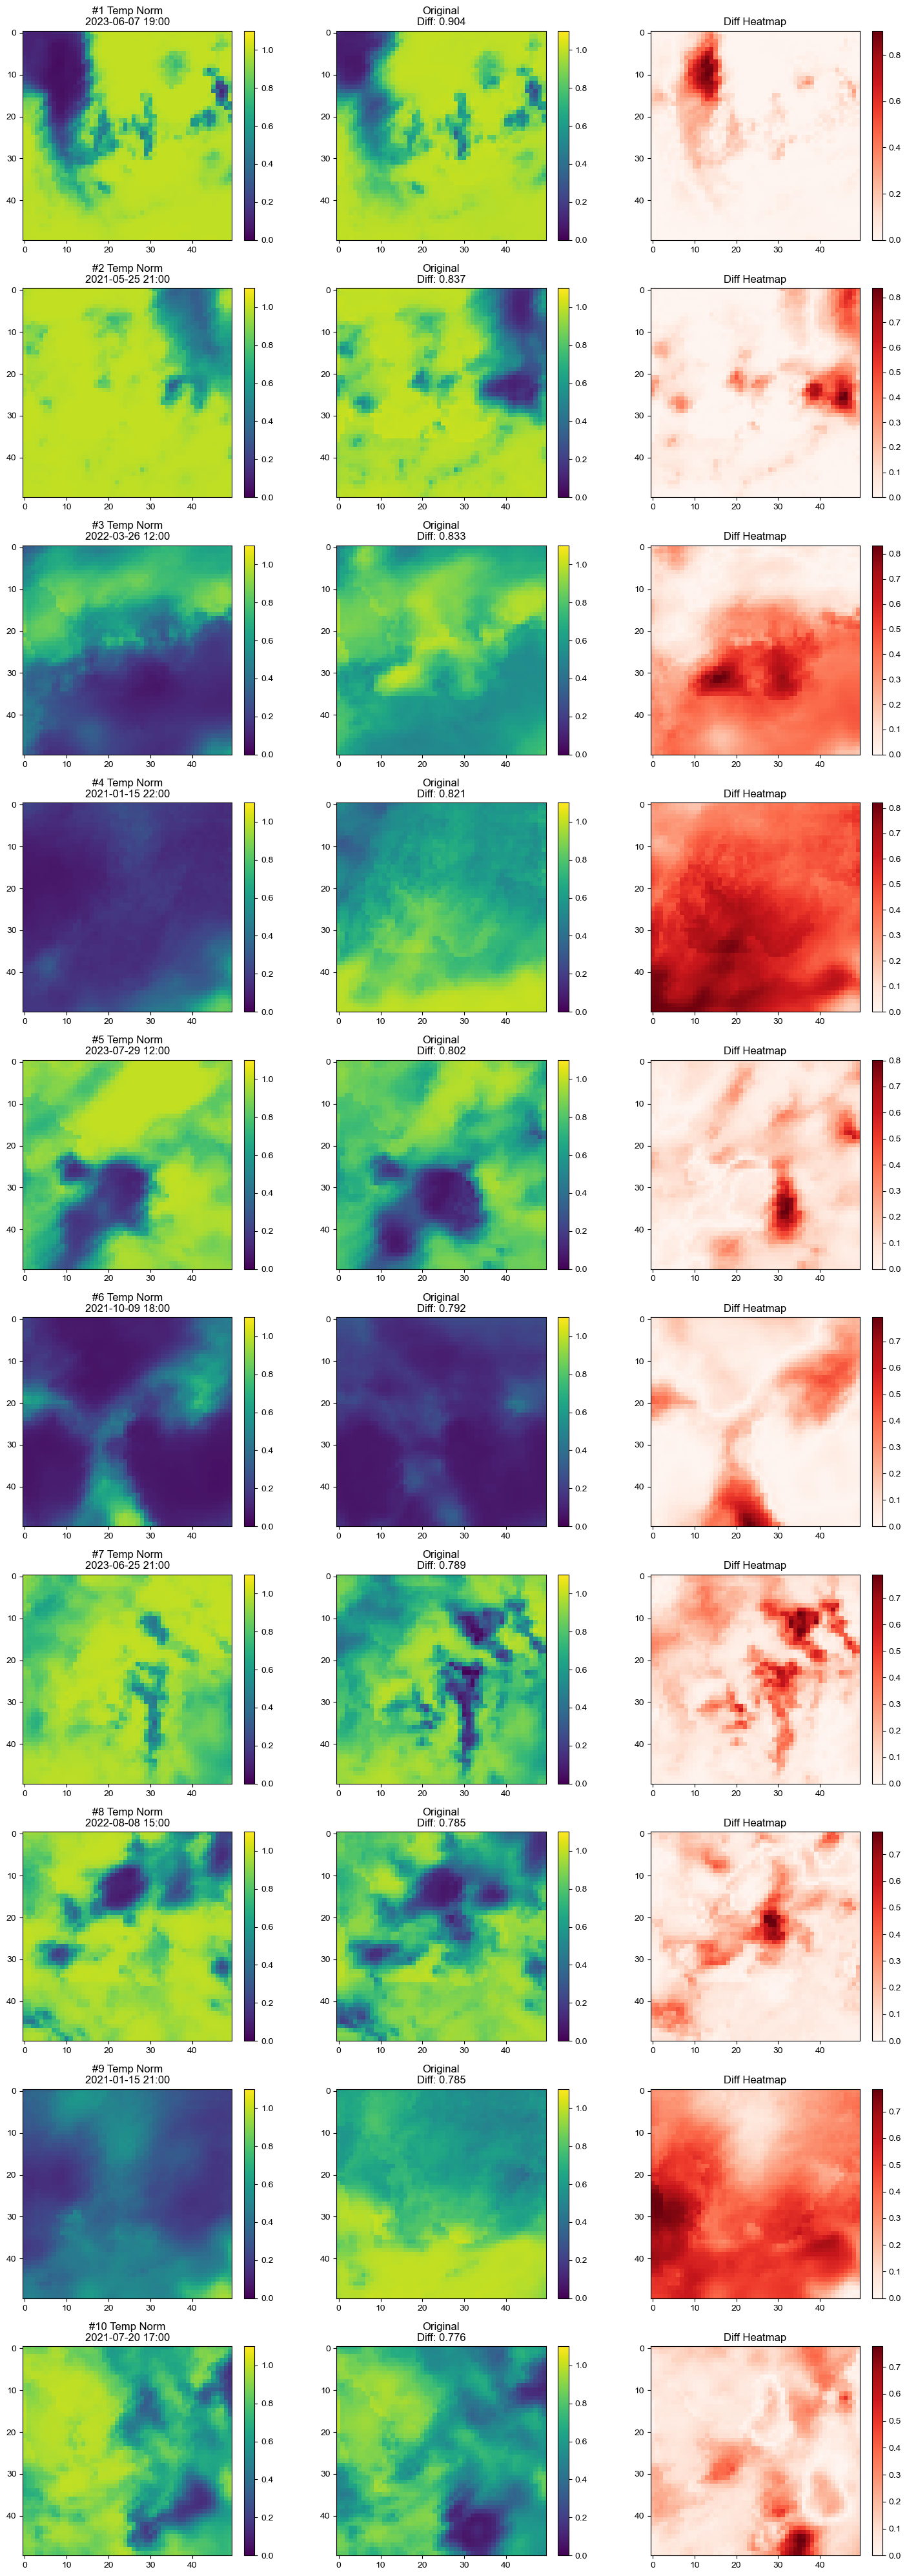

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def show_top_10_differences(path1, path2):
    # 1. Load data
    data1 = np.load(path1)
    data2 = np.load(path2)
    
    csi1 = data1['csi']
    csi2 = data2['csi']
    times = data1['time_hourly']
    
    # 2. Calculate pointwise absolute difference
    # Shape: (T, 1, 50, 50)
    diff = np.abs(csi1 - csi2)
    
    # 3. Find max difference in each frame
    # We flatten the spatial dims to find the peak error per time step
    max_err_per_frame = np.max(diff, axis=(1, 2, 3))
    
    # 4. Get the indices of the top 10 largest differences (sorted descending)
    top_10_idx = np.argsort(max_err_per_frame)[-10:][::-1]
    
    print(f"{'Rank':<5} | {'Timestamp (UTC)':<20} | {'Max Diff':<10} | {'Idx':<6}")
    print("-" * 50)

    # 5. Plotting loop
    fig, axes = plt.subplots(10, 3, figsize=(15, 40))
    
    for i, idx in enumerate(top_10_idx):
        ts = pd.to_datetime(times[idx], unit='h', utc=True)
        max_val = max_err_per_frame[idx]
        
        print(f"#{i+1:<4} | {str(ts):<20} | {max_val:.4f}     | {idx:<6}")
        
        # Column 1: Temp Normalized
        im1 = axes[i, 0].imshow(csi1[idx, 0], vmin=0, vmax=1.1, cmap='viridis')
        axes[i, 0].set_title(f"#{i+1} Temp Norm\n{ts.strftime('%Y-%m-%d %H:%M')}")
        plt.colorbar(im1, ax=axes[i, 0], fraction=0.046, pad=0.04)
        
        # Column 2: Original
        im2 = axes[i, 1].imshow(csi2[idx, 0], vmin=0, vmax=1.1, cmap='viridis')
        axes[i, 1].set_title(f"Original\nDiff: {max_val:.3f}")
        plt.colorbar(im2, ax=axes[i, 1], fraction=0.046, pad=0.04)
        
        # Column 3: Difference Heatmap
        im3 = axes[i, 2].imshow(diff[idx, 0], cmap='Reds', vmin=0, vmax=max_val)
        axes[i, 2].set_title("Diff Heatmap")
        plt.colorbar(im3, ax=axes[i, 2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

# Execution
path_norm = "Data/syntheticCSI/csi_synthetic_hourly_night_fuzzy_pub_temp_norm_nominmax.npz"
path_orig = "Data/syntheticCSI/csi_synthetic_hourly_merged_day_night_fuzzy.npz"

show_top_10_differences(path_norm, path_orig)

In [35]:
cams = np.load("Data/CAMS/csi_cams_hourly_pred_2021_2023.npz")

In [ ]:
import numpy as np
import pandas as pd

def audit_synthetic_npz(file_path):
    # 1. Load the data
    data = np.load(file_path)
    csi = data['csi']
    t_raw = data['time_hourly']
    
    # 2. Check for NaNs
    nan_count = np.isnan(csi).sum()
    nan_indices = np.unique(np.where(np.isnan(csi))[0])
    
    # 3. Check for Gaps in the Timeline
    # Convert raw hours to a sorted DatetimeIndex
    t_dt = pd.to_datetime(t_raw, unit='h', utc=True).sort_values()
    
    # Create the 'perfect' range from start to end (no gaps)
    ideal_range = pd.date_range(start=t_dt.min(), end=t_dt.max(), freq='h', tz='UTC')
    
    # Find which hours are in the ideal range but missing from your file
    gaps = ideal_range.difference(t_dt)
    
    # 4. Report Results
    print(f"--- Audit Report: {file_path.split('/')[-1]} ---")
    print(f"Total Samples: {len(t_raw)}")
    print("-" * 50)
    
    # NaN Results
    if nan_count == 0:
        print("✅ NaNs: None found. The CSI data is numerically clean.")
    else:
        print(f"❌ NaNs Found: {nan_count} total NaN values.")
        print(f"   Affected Samples: {len(nan_indices)} out of {len(t_raw)}")
        
    # Gap Results
    if len(gaps) == 0:
        print("✅ Gaps: None found. The hourly sequence is perfectly continuous.")
    else:
        print(f"❌ Gaps Found: {len(gaps)} hours are missing from the sequence.")
        print(f"   Continuity: {((len(t_raw) / len(ideal_range)) * 100):.2f}% coverage")
        
        if len(gaps) > 0:
            print("\nFirst 5 gaps (UTC):")
            for g in gaps[:5]:
                print(f"  - {g}")

# Execution
file_path = "Data/syntheticCSI/csi_synthetic_hourly_merged_day_night_fuzzy_pub_temp_norm.npz"
audit_synthetic_npz(file_path)

--- Audit Report: csi_synthetic_hourly_merged_day_night_fuzzy.npz ---
Total Samples: 26104
--------------------------------------------------
✅ NaNs: None found. The CSI data is numerically clean.
❌ Gaps Found: 165 hours are missing from the sequence.
   Continuity: 99.37% coverage

First 5 gaps (UTC):
  - 2021-01-06 11:00:00+00:00
  - 2021-01-10 09:00:00+00:00
  - 2021-01-14 21:00:00+00:00
  - 2021-01-15 09:00:00+00:00
  - 2021-01-16 11:00:00+00:00


In [42]:
import numpy as np
import pandas as pd

def check_cams_gaps(file_path):
    # 1. Load the data
    data = np.load(file_path)
    
    # Identify the time key (usually 'time' or 'time_hourly')
    time_key = 'time_hourly' if 'time_hourly' in data.files else 'time'
    t_raw = data[time_key]
    
    print(f"--- Gap Analysis: {file_path.split('/')[-1]} ---")
    print(f"Total samples found: {len(t_raw)}")

    # 2. Convert to Datetime and Sort
    # The 'utc=True' is important for consistency with your other files
    t_dt = pd.to_datetime(t_raw, utc=True).sort_values()
    
    # 3. Define the continuous range (No Gaps)
    start_time = t_dt.min()
    end_time = t_dt.max()
    ideal_range = pd.date_range(start=start_time, end=end_time, freq='h', tz='UTC')
    
    # 4. Calculate Gaps
    # We use sets for a clean comparison
    actual_set = set(t_dt)
    ideal_set = set(ideal_range)
    
    missing_hours = sorted(list(ideal_set - actual_set))
    
    # 5. Report Results
    gap_count = len(missing_hours)
    
    if gap_count == 0:
        print("✅ Continuity: This file is a perfectly continuous hourly sequence.")
    else:
        print(f"❌ Gaps Found: {gap_count} missing hours.")
        print(f"   Time Range: {start_time} to {end_time}")
        print(f"   Coverage:   {(len(t_dt) / len(ideal_range) * 100):.2f}%")
        
        # Display the first few gaps to see if they are clustered
        print("\nFirst 10 missing timesteps (UTC):")
        for g in missing_hours[:10]:
            print(f"  - {g}")
            
        # Check for large blocks
        df_missing = pd.Series(missing_hours)
        if len(df_missing) > 1:
            diffs = df_missing.diff()
            large_gaps = diffs[diffs > pd.Timedelta(hours=1)]
            if not large_gaps.empty:
                print(f"\n⚠️ Alert: Found {len(large_gaps)} significant jump(s) in the timeline.")

# Run the check
path_cams = "Data/CAMS/csi_cams_hourly_pred_2021_2023.npz"
check_cams_gaps(path_cams)

--- Gap Analysis: csi_cams_hourly_pred_2021_2023.npz ---
Total samples found: 26269
✅ Continuity: This file is a perfectly continuous hourly sequence.
